# General Libraries

In [1401]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Data

In [1402]:
df = pd.read_excel(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Material\2. Interviews & Surveys\3. Quantitative Survey\Tourism surveyEncuesta de turismo.xlsx")

In [1403]:
# Leave only needed columns
df = df.iloc[:,6:]

In [1404]:
df.columns = [
    "travel_attributes_importance",
    "att_central_accommodation",
    "att_accommodation_services",
    "define_accommodation",
    "accommodation_search",
    "att_less_crowded_destinations",
    "less_crowded_willingness",
    "extra_travel_time",
    "att_heritage_ambience",
    "att_attractions_density",
    "att_guided_tours_flexibility",
    "city_tour_interest",
    "city_tour_type",
    "architectural_interest",
    "att_local_restaurants_diversity",
    "eating_preference",
    "restaurant_choice",
    "att_natural_areas_proximity",
    "natural_environment_type",
    "att_tourist_info_availability",
    "att_museums_art_availability",
    "too_cheap",
    "cheap",
    "expensive",
    "too_expensive",
    "visited_ascoli",
    "recommend_ascoli",
    "ascoli_likelihood",
    "heard_ascoli",
    "ascoli_attractiveness",
    "age_group",
    "gender",
    "residence",
    "occupation"]

In [1405]:
# Replace some cases
df['city_tour_type'] = df['city_tour_type'].replace({"free tour": "Guided walking tour (Tour guiado a pie)"})

df['occupation'] = df['occupation'].replace({"Justicia": "Employed (Empleado/a)"})

In [1406]:
df.head(2)

,travel_attributes_importance,att_central_accommodation,att_accommodation_services,define_accommodation,accommodation_search,att_less_crowded_destinations,less_crowded_willingness,extra_travel_time,att_heritage_ambience,att_attractions_density,...,too_expensive,visited_ascoli,recommend_ascoli,ascoli_likelihood,heard_ascoli,ascoli_attractiveness,age_group,gender,residence,occupation
0,Diversity of authentic local restaurants (Dive...,Agree (De acuerdo),Agree (De acuerdo),…book at the last minute (reservar a último mo...,Online platforms as Booking (En plataformas on...,Strongly diasgree (Totalmente en desacuerdo),2,1–2 hours (1-2 horas),Agree (De acuerdo),Disagree (En desacuerdo),...,250,No,NaN,10.0,No,7,18-25,Female (Femenino),South America (América del Sur),Employed (Empleado/a)
1,Heritage ambience of the historic center (Ambi...,Neutral,Neutral,…book in advance during the planning phase (re...,Online platforms as Booking (En plataformas on...,Neutral,3,3–4 hours (3-4 horas),Neutral,Neutral,...,100,No,NaN,5.0,Yes (Si),6,18-25,Male (Masculino),South America (América del Sur),Employed (Empleado/a)


# Ranking Consistency

In [1407]:
def attributes(row):
    attribute = [a.strip() for a in row.split(";") if a.strip()]
    return {a: i+1 for i, a in enumerate(attribute)}

df_attributes = df["travel_attributes_importance"].apply(attributes)

df_attributes = pd.DataFrame(df_attributes.tolist())

df_attributes.columns = [
    "Diversity of authentic local restaurants",
    "Density of touristic attractions within walking distance",
    "City located outside major tourist circuits",
    "Availability of tourist information, both digital and on-site",
    "Availability of centrally located accommodation",
    "Availability of museums and art venues",
    "Accommodation services, such as flexible cancellation, digital check-in, amenities, etc.",
    "Heritage ambience of the historic center",
    "Proximity to natural areas or outdoor routes",
    "Flexible scheduling of guided tours"]

df_attributes

,Diversity of authentic local restaurants,Density of touristic attractions within walking distance,City located outside major tourist circuits,"Availability of tourist information, both digital and on-site",Availability of centrally located accommodation,Availability of museums and art venues,"Accommodation services, such as flexible cancellation, digital check-in, amenities, etc.",Heritage ambience of the historic center,Proximity to natural areas or outdoor routes,Flexible scheduling of guided tours
0,1,2,3,4,5,6,7,8,9,10
1,2,10,6,8,4,3,9,1,5,7
2,5,6,10,9,2,4,7,1,3,8
3,10,2,7,8,3,5,4,1,6,9
4,1,3,5,6,2,9,7,4,8,10
...,...,...,...,...,...,...,...,...,...,...
120,3,9,6,5,2,4,1,7,8,10
121,4,7,3,9,6,5,10,2,1,8
122,7,6,10,2,1,9,3,8,4,5
123,8,2,6,9,7,4,5,3,1,10


In [1408]:
df_attributes.to_excel('attributes_for_clustering.xlsx')

In [1409]:
df_inverted = df_attributes.copy()
df_inverted = 11 - df_inverted

In [1410]:
df_inverted.head(3)

,Diversity of authentic local restaurants,Density of touristic attractions within walking distance,City located outside major tourist circuits,"Availability of tourist information, both digital and on-site",Availability of centrally located accommodation,Availability of museums and art venues,"Accommodation services, such as flexible cancellation, digital check-in, amenities, etc.",Heritage ambience of the historic center,Proximity to natural areas or outdoor routes,Flexible scheduling of guided tours
0,10,9,8,7,6,5,4,3,2,1
1,9,1,5,3,7,8,2,10,6,4
2,6,5,1,2,9,7,4,10,8,3


In [1411]:
df_ranking_scaled = 1 + (df_inverted - 1) * (4 / 9)

In [1412]:
df_ranking_scaled.head(3)

,Diversity of authentic local restaurants,Density of touristic attractions within walking distance,City located outside major tourist circuits,"Availability of tourist information, both digital and on-site",Availability of centrally located accommodation,Availability of museums and art venues,"Accommodation services, such as flexible cancellation, digital check-in, amenities, etc.",Heritage ambience of the historic center,Proximity to natural areas or outdoor routes,Flexible scheduling of guided tours
0,5.000000,4.555556,4.111111,3.666667,3.222222,2.777778,2.333333,1.888889,1.444444,1.000000
1,4.555556,1.000000,2.777778,1.888889,3.666667,4.111111,1.444444,5.000000,3.222222,2.333333
2,3.222222,2.777778,1.000000,1.444444,4.555556,3.666667,2.333333,5.000000,4.111111,1.888889


In [1413]:
# Likert questions
cols = [
    "att_central_accommodation",
    "att_accommodation_services",
    "att_less_crowded_destinations",
    "att_heritage_ambience",
    "att_attractions_density",
    "att_guided_tours_flexibility",
    "att_local_restaurants_diversity",
    "att_natural_areas_proximity",
    "att_tourist_info_availability",
    "att_museums_art_availability"
]

df_likert = df[cols]

value_map = {
    "Strongly diasgree (Totalmente en desacuerdo)": 1,
    "Disagree (En desacuerdo)": 2,
    "Neutral": 3,
    "Agree (De acuerdo)": 4,
    "Strongly agree (Totalmente de acuerdo)": 5
}

df_likert[cols] = df_likert[cols].replace(value_map)

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\1243115299.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_likert[cols] = df_likert[cols].replace(value_map)
C:\Users\franc\AppData\Local\Temp\ipykernel_12100\1243115299.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_likert[cols] = df_likert[cols].replace(value_map)


In [1414]:
# Order columns according to attributes dataframe

df_likert = df_likert[["att_local_restaurants_diversity", "att_attractions_density", "att_less_crowded_destinations",
                       "att_tourist_info_availability", "att_central_accommodation", "att_museums_art_availability",
                       "att_accommodation_services", "att_heritage_ambience", "att_natural_areas_proximity",
                       "att_guided_tours_flexibility"]]

In [1415]:
df_likert.head(3)

,att_local_restaurants_diversity,att_attractions_density,att_less_crowded_destinations,att_tourist_info_availability,att_central_accommodation,att_museums_art_availability,att_accommodation_services,att_heritage_ambience,att_natural_areas_proximity,att_guided_tours_flexibility
0,4,2,1,4,4,1,4,4,4,2
1,3,3,3,3,3,3,3,3,3,3
2,2,2,4,1,3,3,3,5,5,1


In [1416]:
from scipy.stats import spearmanr

corrs = []
for i in range(len(df_ranking_scaled.columns)):
    x = df_ranking_scaled.iloc[:, i]
    y = df_likert.iloc[:, i]
    
    # Spearman correlation and p-value
    rho, p = spearmanr(x, y)
    
    corrs.append({
        'Attribute': df_ranking_scaled.columns[i],
        'Spearman_rho': rho,
        'p_value': p
    })

result = pd.DataFrame(corrs)

def sig_label(p):
    if p < 0.0001:
        return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

result['Significance'] = result['p_value'].apply(sig_label)

result['Spearman_rho'] = result['Spearman_rho'].round(3)
result['p_value'] = result['p_value'].round(4)

result

,Attribute,Spearman_rho,p_value,Significance
0,Diversity of authentic local restaurants,0.441,0.0000,****
1,Density of touristic attractions within walkin...,0.470,0.0000,****
2,City located outside major tourist circuits,0.208,0.0201,*
3,"Availability of tourist information, both digi...",0.582,0.0000,****
4,Availability of centrally located accommodation,0.414,0.0000,****
5,Availability of museums and art venues,0.596,0.0000,****
6,"Accommodation services, such as flexible cance...",0.451,0.0000,****
7,Heritage ambience of the historic center,0.526,0.0000,****
8,Proximity to natural areas or outdoor routes,0.529,0.0000,****
9,Flexible scheduling of guided tours,0.465,0.0000,****


Spearman's rank correlation coefficient or Spearman's ρ is a number ranging from -1 to 1 that indicates how strongly two sets of ranks are correlated.

In [1417]:
likert_counts = df_likert.apply(lambda x: x.value_counts()).fillna(0).astype(int)
likert_counts = likert_counts.reindex([1, 2, 3, 4, 5])
likert_counts_T = likert_counts.T

def highlight_top2(s):
    is_top2 = s >= s.nlargest(2).min()
    return ['background-color: green' if v else '' for v in is_top2]

likert_counts_T.style.apply(highlight_top2, axis=1)

,1,2,3,4,5
att_local_restaurants_diversity,0,9,26,47,43
att_attractions_density,3,7,29,53,33
att_less_crowded_destinations,4,6,37,53,25
att_tourist_info_availability,3,11,29,53,29
att_central_accommodation,4,5,18,67,31
att_museums_art_availability,7,10,41,50,17
att_accommodation_services,4,5,27,58,31
att_heritage_ambience,4,6,20,55,40
att_natural_areas_proximity,1,6,40,55,23
att_guided_tours_flexibility,17,16,36,37,19


# K-Mean

This method was replicated as in the previous work (PW), but after some research it was decided to use Gower distance + K-Medoids, as the previous methodology is useful for continuous data, not ordinal values.

## Libraries

In [1418]:
# Clustering Algorithms
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

# Cluster Evaluation
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from scipy.stats import kendalltau
from scipy.spatial.distance import squareform

# Visualization
from yellowbrick.cluster import KElbowVisualizer
from sklearn.manifold import TSNE

## Defining Optimal K

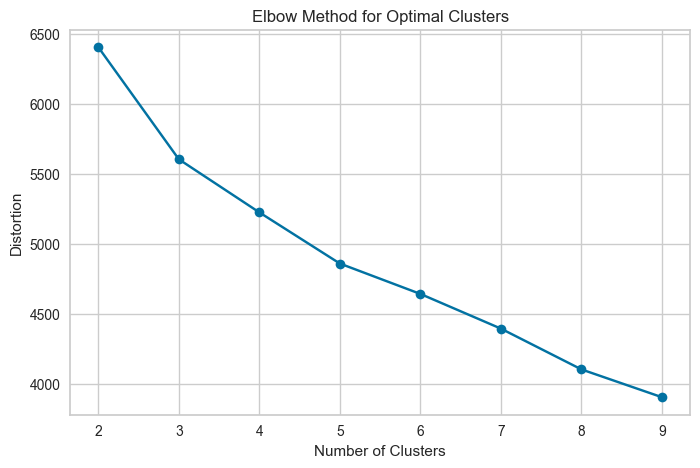

In [1419]:
# Elbow
distortions = []
K = range(2, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_attributes)
    distortions.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, distortions, marker='o')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')
plt.show()

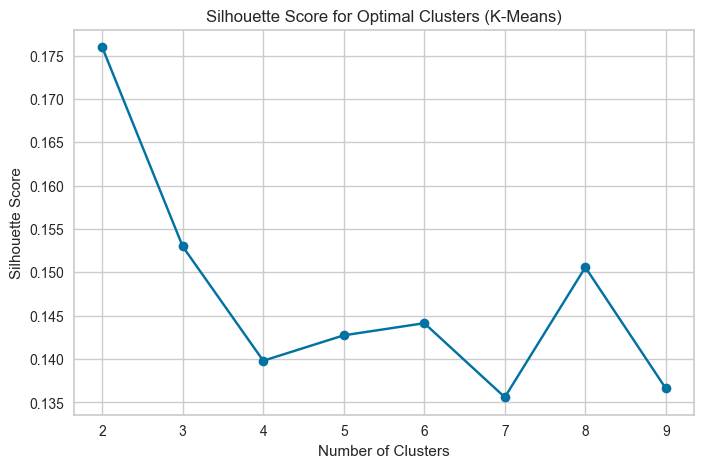

In [1420]:
# Silhouette
K = range(2, 10)
silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_attributes)
    score = silhouette_score(df_attributes, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal Clusters (K-Means)')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

For n_clusters = 2 The average silhouette_score is : 0.15820062639720917
For n_clusters = 3 The average silhouette_score is : 0.14647125443231815
For n_clusters = 4 The average silhouette_score is : 0.146037147256319
For n_clusters = 5 The average silhouette_score is : 0.09405441024246722
For n_clusters = 6 The average silhouette_score is : 0.13231025502946092


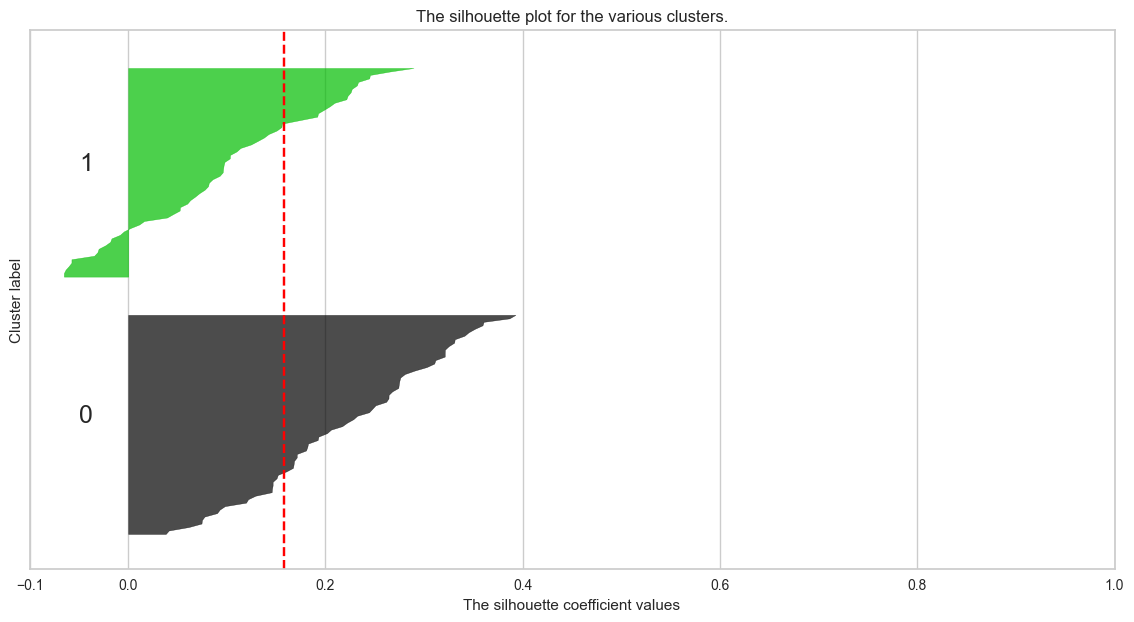

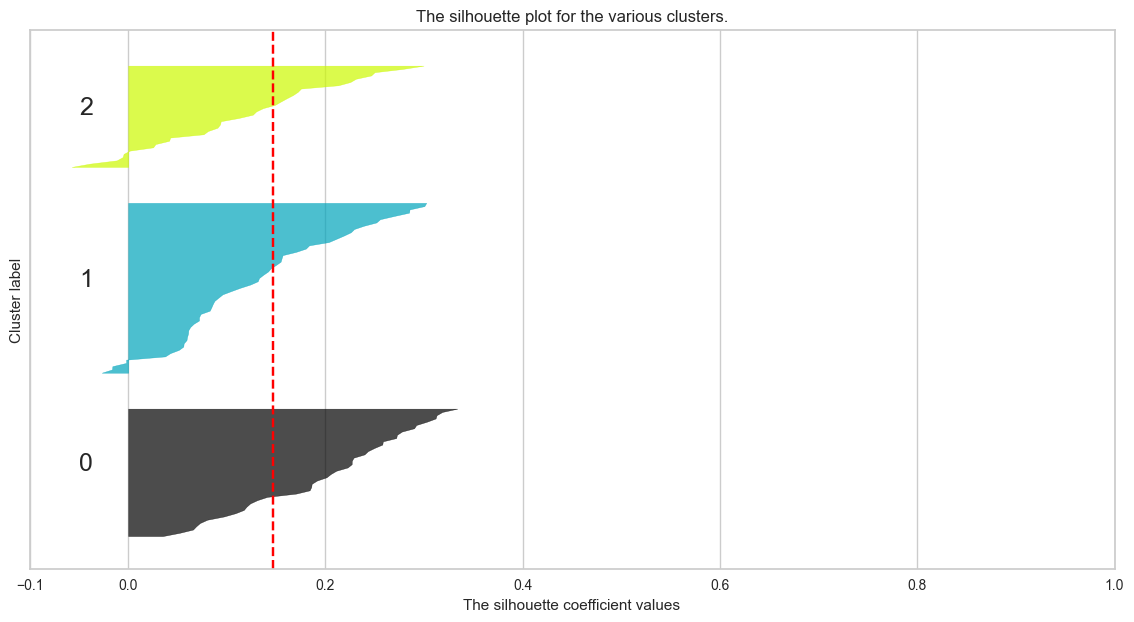

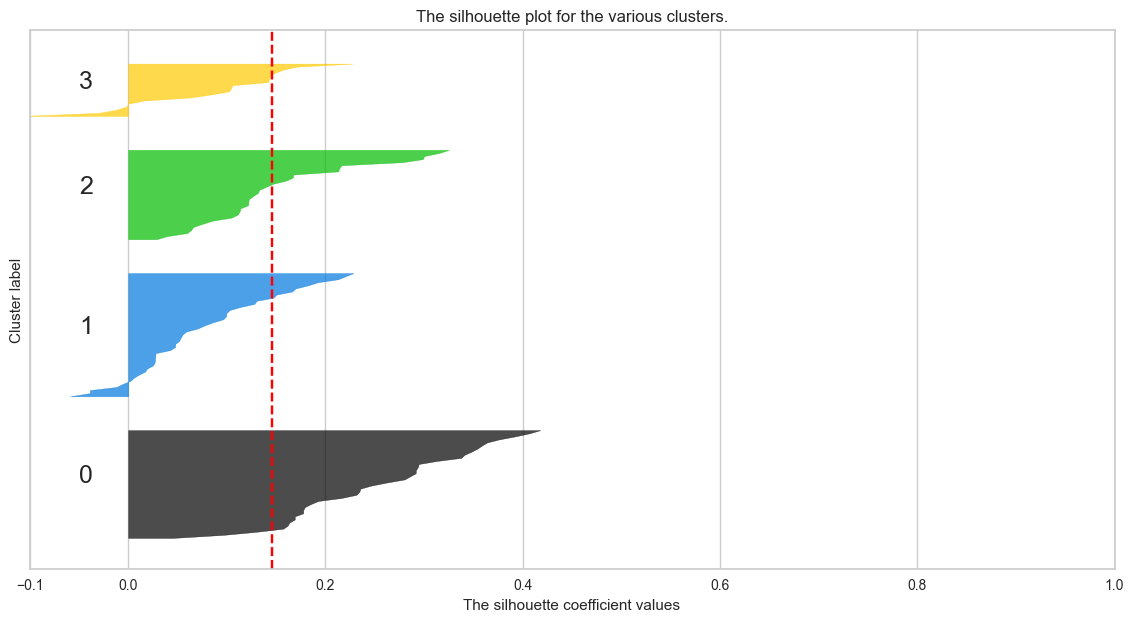

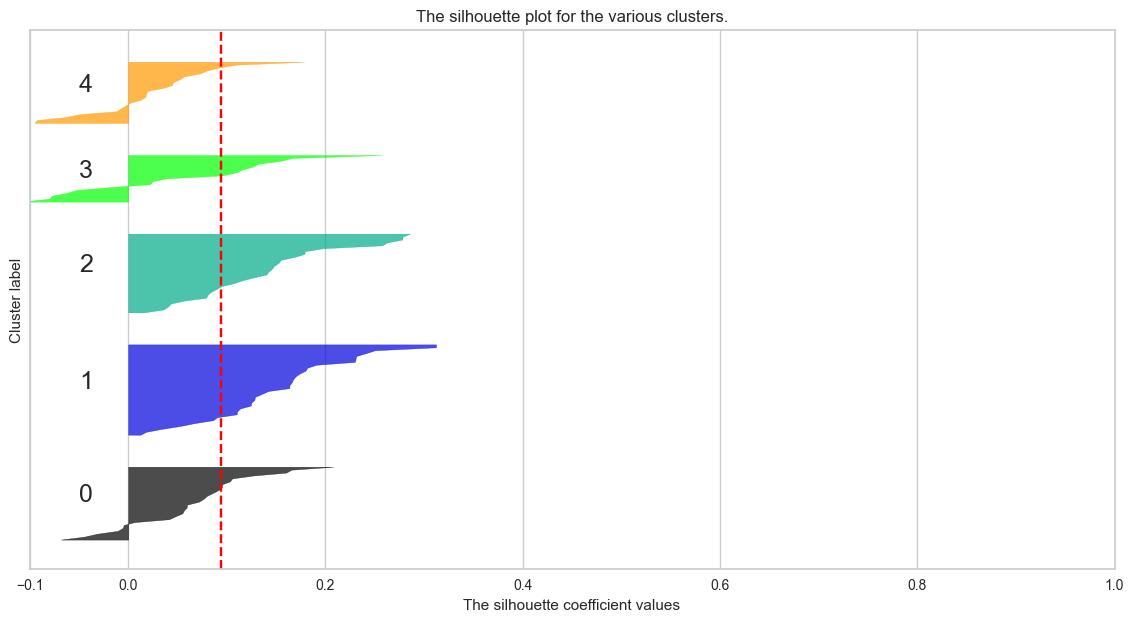

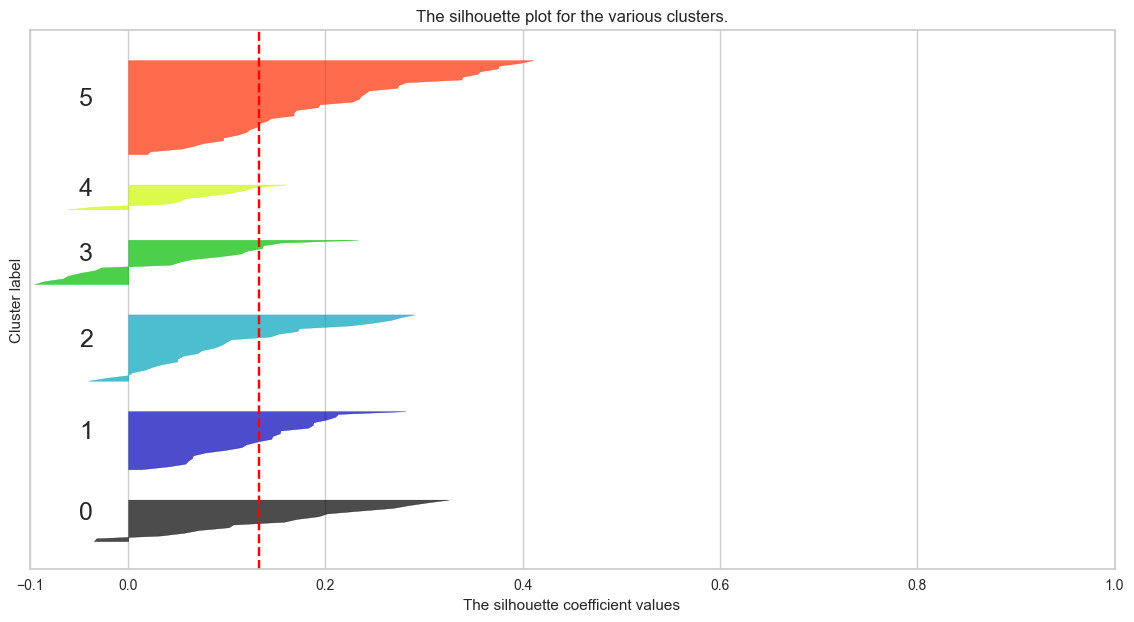

In [1421]:
import matplotlib.cm as cm

X = df_attributes.to_numpy()
range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    fig, ax = plt.subplots()
    fig.set_size_inches(14, 7)

    # Silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters,random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax.set_title("The silhouette plot for the various clusters.")
    ax.set_xlabel("The silhouette coefficient values")
    ax.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax.set_yticks([])  # Clear the yaxis labels / ticks
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

In [1422]:
optimal_k = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for k in optimal_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(df_attributes)

    db_index = davies_bouldin_score(df_attributes, cluster_labels)
    print(f"Davies-Bouldin Index for k={k}: {db_index}")

Davies-Bouldin Index for k=2: 2.0976157497688757
Davies-Bouldin Index for k=3: 1.9409886824193645
Davies-Bouldin Index for k=4: 1.843956845691695
Davies-Bouldin Index for k=5: 1.8105677389150348
Davies-Bouldin Index for k=6: 1.7741300679978285
Davies-Bouldin Index for k=7: 1.8115719625987723
Davies-Bouldin Index for k=8: 1.7275438558021956
Davies-Bouldin Index for k=9: 1.6954815460142174
Davies-Bouldin Index for k=10: 1.6710468119146888


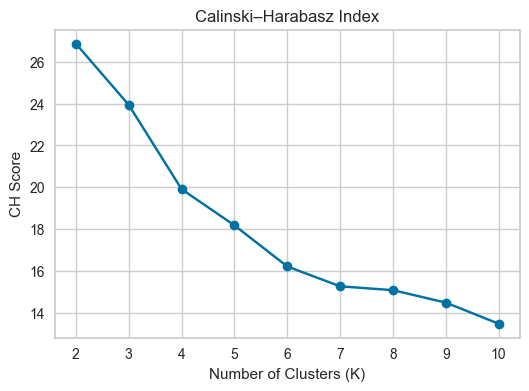

In [1423]:
K_range = range(2, 11)
ch_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

    ch = calinski_harabasz_score(X, labels)
    ch_scores.append(ch)

plt.figure(figsize=(6,4))
plt.plot(K_range, ch_scores, marker='o')
plt.title('Calinski–Harabasz Index')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('CH Score')
plt.grid(True)
plt.show()

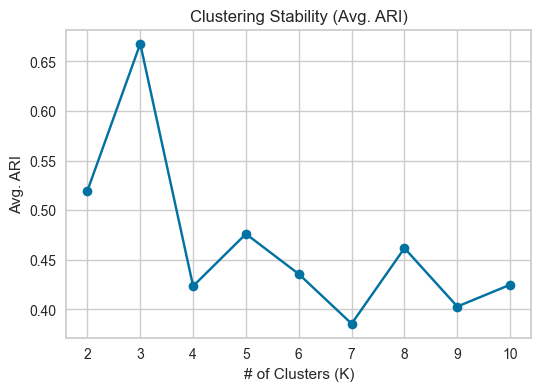

In [1424]:
K_range = range(2, 11)
n_runs = 5  # repetition of clustering by K

mean_ari_scores = []

for k in K_range:
    labels_list = []

    # Several runs by K
    for seed in range(n_runs):
        kmeans = KMeans(n_clusters=k, random_state=seed)
        labels = kmeans.fit_predict(X)
        labels_list.append(labels)
    
    # Average ARI
    ari_scores = []
    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            ari = adjusted_rand_score(labels_list[i], labels_list[j])
            ari_scores.append(ari)
    
    mean_ari = np.mean(ari_scores)
    mean_ari_scores.append(mean_ari)

plt.figure(figsize=(6,4))
plt.plot(K_range, mean_ari_scores, marker='o')
plt.title('Clustering Stability (Avg. ARI)')
plt.xlabel('# of Clusters (K)')
plt.ylabel('Avg. ARI')
plt.grid(True)
plt.show()

# Final Clustering

After some research, a better way to find optimal K is to use Gower distance + K-medoids, as we are using ordinal data.
For technical reasons, the analysis of optimal K was done in Google Colab, and from now onwards the .xlsx obtained is used

In [1425]:
df_attributes = pd.read_excel(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Material\2. Interviews & Surveys\3. Quantitative Survey\four_clusters.xlsx")

In [1426]:
df_attributes

,Diversity of authentic local restaurants,Density of touristic attractions within walking distance,City located outside major tourist circuits,"Availability of tourist information, both digital and on-site",Availability of centrally located accommodation,Availability of museums and art venues,"Accommodation services, such as flexible cancellation, digital check-in, amenities, etc.",Heritage ambience of the historic center,Proximity to natural areas or outdoor routes,Flexible scheduling of guided tours,cluster
0,1,2,3,4,5,6,7,8,9,10,0
1,2,10,6,8,4,3,9,1,5,7,3
2,5,6,10,9,2,4,7,1,3,8,0
3,10,2,7,8,3,5,4,1,6,9,1
4,1,3,5,6,2,9,7,4,8,10,0
...,...,...,...,...,...,...,...,...,...,...,...
120,3,9,6,5,2,4,1,7,8,10,2
121,4,7,3,9,6,5,10,2,1,8,3
122,7,6,10,2,1,9,3,8,4,5,2
123,8,2,6,9,7,4,5,3,1,10,2


In [1427]:
df_attributes['cluster'] = df_attributes['cluster'].replace({0: 1, 1: 2, 2: 3, 3: 4})

In [1428]:
df_clustering = df_attributes

In [1429]:
df_clustering.head(2)

,Diversity of authentic local restaurants,Density of touristic attractions within walking distance,City located outside major tourist circuits,"Availability of tourist information, both digital and on-site",Availability of centrally located accommodation,Availability of museums and art venues,"Accommodation services, such as flexible cancellation, digital check-in, amenities, etc.",Heritage ambience of the historic center,Proximity to natural areas or outdoor routes,Flexible scheduling of guided tours,cluster
0,1,2,3,4,5,6,7,8,9,10,1
1,2,10,6,8,4,3,9,1,5,7,4


In [1430]:
#Segment sizes:

df_clustering_sizes = pd.DataFrame(df_clustering.groupby("cluster").size(),columns=["Size"]).T
df_clustering_sizes.insert(0,"Population",len(df_attributes))
df_clustering_sizes.loc["%"] = df_clustering_sizes.iloc[0].div(df_clustering_sizes.iloc[0,0]).mul(100).astype(int)
df_clustering_sizes

cluster,Population,1,2,3,4
Size,125,35,36,23,31
%,100,28,28,18,24


In [1431]:
# Means of segmentation variables by segment:

from scipy import stats

df_clustering_Means = df_clustering.groupby("cluster").mean().T
df_clustering_Means.insert(0,"Population",df_clustering.drop(columns="cluster").mean())

X = df_clustering.copy()

def style_cols(col):
    if col.name == "Population":
        return ["background-color: #616161; color: white"] * len(col)

    segment = X[X["cluster"] == col.name]
    rest_pop = X[X["cluster"] != col.name]

    colors = []
    for var_name, var_segment_mean in col.items():
        if var_name not in X.columns:
            colors.append("background-color: #424242; color: white")
            continue

        t_stat, p_value = stats.ttest_ind(
            segment[var_name],
            rest_pop[var_name],
            equal_var=False,
            nan_policy="omit"
        )

        if p_value < 0.05:
            color = "#00C853" if var_segment_mean > rest_pop[var_name].mean() else "#D50000"
        elif p_value < 0.1:
            color = "#69F0AE" if var_segment_mean > rest_pop[var_name].mean() else "#FF8A80"
        else:
            color = "#424242"
        
        colors.append(f"background-color: {color}; color: white;")

    return colors

df_clustering_Means.style.apply(style_cols, axis=0).format("{:.2f}")

cluster,Population,1,2,3,4
Diversity of authentic local restaurants,3.92,3.29,4.17,5.61,3.10
Density of touristic attractions within walking distance,5.89,3.77,4.36,7.39,8.94
City located outside major tourist circuits,7.12,7.66,8.28,6.83,5.39
"Availability of tourist information, both digital and on-site",6.41,5.71,7.42,5.39,6.77
Availability of centrally located accommodation,4.28,4.23,4.36,3.26,5.00
Availability of museums and art venues,5.04,6.66,4.14,5.65,3.81
"Accommodation services, such as flexible cancellation, digital check-in, amenities, etc.",5.67,6.77,4.89,2.78,7.48
Heritage ambience of the historic center,3.23,3.77,2.33,5.26,2.16
Proximity to natural areas or outdoor routes,5.29,4.80,7.06,5.43,3.68
Flexible scheduling of guided tours,8.15,8.34,8.00,7.39,8.68


In [1432]:
from pca import pca

features = df_clustering.drop(columns="cluster")
segments = df_clustering.cluster

general_pca = pca()

results = general_pca.fit_transform(features)

results.keys()

[25-10-2025 18:35:59] [pca.pca] [INFO] Extracting column labels from dataframe.
[25-10-2025 18:35:59] [pca.pca] [INFO] Extracting row labels from dataframe.
[25-10-2025 18:35:59] [pca.pca] [INFO] PCA reduction performed to capture 95.0% explained variance using 10 columns of the input data.
[25-10-2025 18:35:59] [pca.pca] [INFO] Fit using PCA.
[25-10-2025 18:35:59] [pca.pca] [INFO] Compute loadings and PCs.
[25-10-2025 18:35:59] [pca.pca] [INFO] Compute explained variance.
[25-10-2025 18:35:59] [pca.pca] [INFO] Number of components is 8 that covers 95.00% explained variance.
[25-10-2025 18:35:59] [pca.pca] [INFO] The PCA reduction is performed on the 10 columns of the input dataframe.
[25-10-2025 18:35:59] [pca.pca] [INFO] Fit using PCA.
[25-10-2025 18:35:59] [pca.pca] [INFO] Compute loadings and PCs.
[25-10-2025 18:35:59] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[8]
[25-10-2025 18:35:59] [pca.pca] [INFO] Multiple test correction app

dict_keys(['loadings', 'PC', 'explained_var', 'variance_ratio', 'model', 'scaler', 'pcp', 'topfeat', 'outliers', 'outliers_params'])

In [1433]:
var_exp = general_pca.results['variance_ratio'] * 100
var_exp_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(var_exp))],
    'Explained Variance (%)': var_exp
})

print(var_exp_df.round(2))

  Component  Explained Variance (%)
0       PC1                   24.82
1       PC2                   18.62
2       PC3                   14.09
3       PC4                   10.05
4       PC5                    9.43
5       PC6                    7.02
6       PC7                    6.49
7       PC8                    5.09
8       PC9                    4.39
9      PC10                    0.00


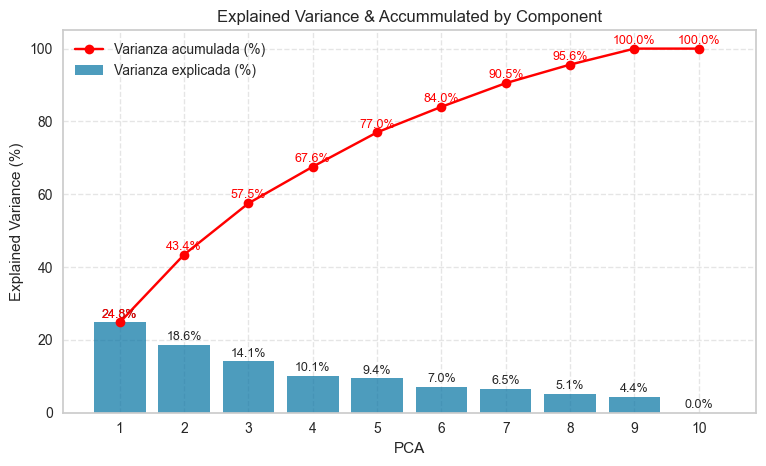

In [1434]:
acum_var_exp = np.cumsum(var_exp)
components = np.arange(1, len(var_exp) + 1)

plt.figure(figsize=(8, 5))

plt.bar(components, var_exp, alpha=0.7, label='Varianza explicada (%)')

for i, v in enumerate(var_exp):
    plt.text(i + 1, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)

plt.plot(components, acum_var_exp, marker='o', color='red', label='Varianza acumulada (%)')

for i, v in enumerate(acum_var_exp):
    plt.text(i + 1, v + 0.5, f"{v:.1f}%", color='red', ha='center', va='bottom', fontsize=9)

plt.title('Explained Variance & Accummulated by Component')
plt.xlabel('PCA')
plt.ylabel('Explained Variance (%)')
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [1435]:
general_pca.results['loadings']

,Diversity of authentic local restaurants,Density of touristic attractions within walking distance,City located outside major tourist circuits,"Availability of tourist information, both digital and on-site",Availability of centrally located accommodation,Availability of museums and art venues,"Accommodation services, such as flexible cancellation, digital check-in, amenities, etc.",Heritage ambience of the historic center,Proximity to natural areas or outdoor routes,Flexible scheduling of guided tours
PC1,-0.193177,0.289868,-0.312948,0.306483,0.247521,-0.360239,0.423887,-0.383364,-0.299655,0.281622
PC2,0.011812,0.635318,-0.387094,-0.271777,0.086325,0.159757,-0.286691,0.394022,-0.318716,-0.022955
PC3,-0.235027,0.533200,0.269948,0.209597,-0.482587,-0.332346,-0.244580,-0.084998,0.365058,0.001736
PC4,-0.354197,-0.290830,-0.285717,0.505862,-0.194744,0.255360,-0.292976,0.263332,-0.044433,0.438343
PC5,-0.515793,0.037983,0.080222,-0.465584,-0.304162,0.267489,0.537539,0.111031,0.046895,0.204380
PC6,-0.328346,-0.047515,-0.188284,-0.290479,0.556420,-0.142364,-0.253460,-0.064718,0.584255,0.174491
PC7,-0.507869,0.023533,0.576167,0.137137,0.396039,0.038751,-0.152749,0.099408,-0.385437,-0.224979
PC8,0.216644,-0.010141,0.346280,-0.324685,-0.036829,-0.044891,-0.310725,-0.256460,-0.276115,0.696921


[25-10-2025 18:36:00] [pca.pca] [INFO] Plot PC1 vs PC2 with loadings.
[25-10-2025 18:36:00] [scatterd.scatterd] [INFO] Add density layer
[25-10-2025 18:36:00] [scatterd.scatterd] [INFO] Create scatterplot


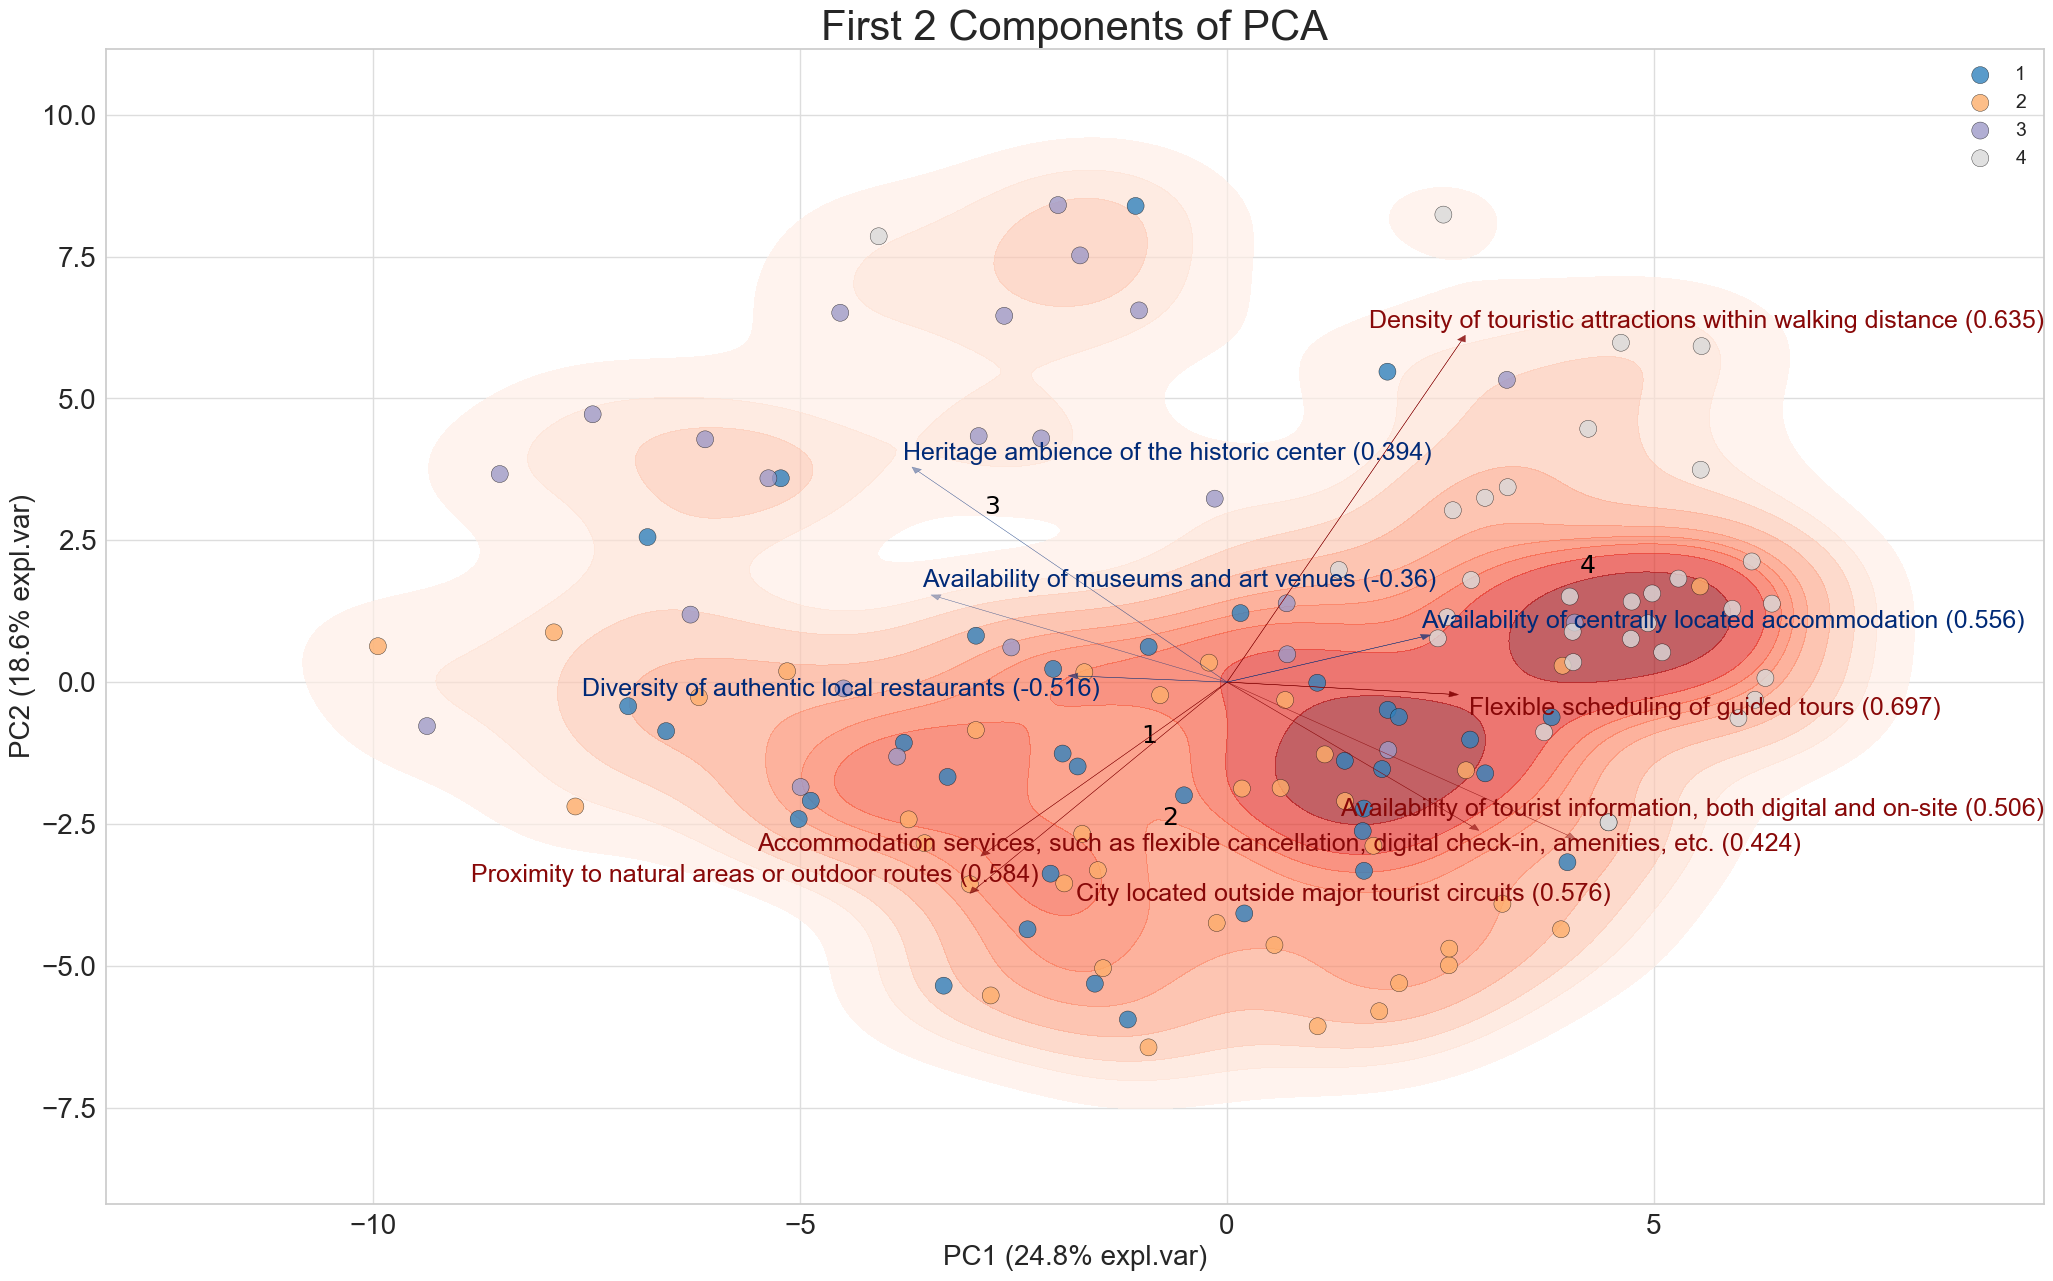

In [ ]:
# Biplot
fig, ax = general_pca.biplot(
    labels=segments,
    density=True,
    legend=True,
    n_feat=10,
)

ax.set_title("First 2 Components of PCA", fontsize=30)

plt.show()

The other plots are in Google Colab, to complement these.

# Random Forest

In [1437]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [1438]:
X = df_clustering.drop(columns="cluster")
y = df_clustering.cluster

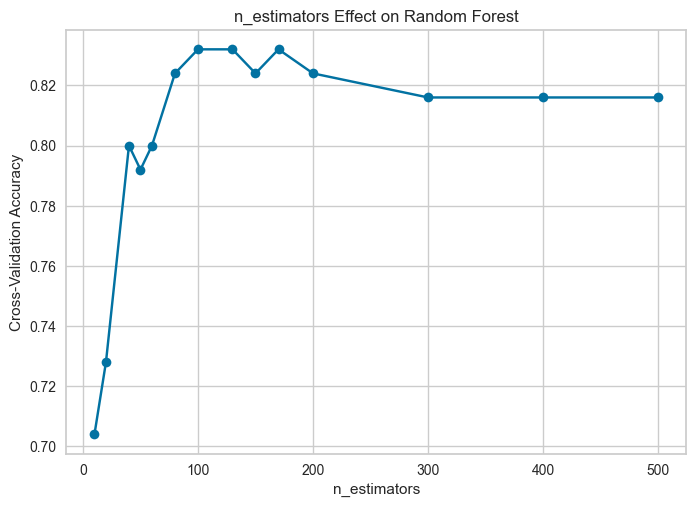

In [1439]:
n_list = [10, 20, 40, 50, 60, 80, 100, 130, 150, 170, 200, 300, 400, 500]
scores = []

for n in n_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    score = cross_val_score(rf, X, y, cv=5).mean()
    scores.append(score)

plt.plot(n_list, scores, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("Cross-Validation Accuracy")
plt.title("n_estimators Effect on Random Forest")
plt.show()

In [1440]:
rf = RandomForestClassifier(
    n_estimators=170,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

,n_estimators,170
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [1441]:
importances = pd.DataFrame([rf.feature_importances_], columns=X.columns, index=["Importance"])
importances = importances.T  # Transpose for better readability
importances = importances.sort_values(by="Importance", ascending=False)  # Sort descending
print(importances.round(2))

                                                    Importance
Density of touristic attractions within walking...        0.21
Accommodation services, such as flexible cancel...        0.16
Proximity to natural areas or outdoor routes              0.13
Availability of museums and art venues                    0.11
City located outside major tourist circuits               0.08
Heritage ambience of the historic center                  0.08
Availability of tourist information, both digit...        0.07
Diversity of authentic local restaurants                  0.07
Availability of centrally located accommodation           0.06
Flexible scheduling of guided tours                       0.03


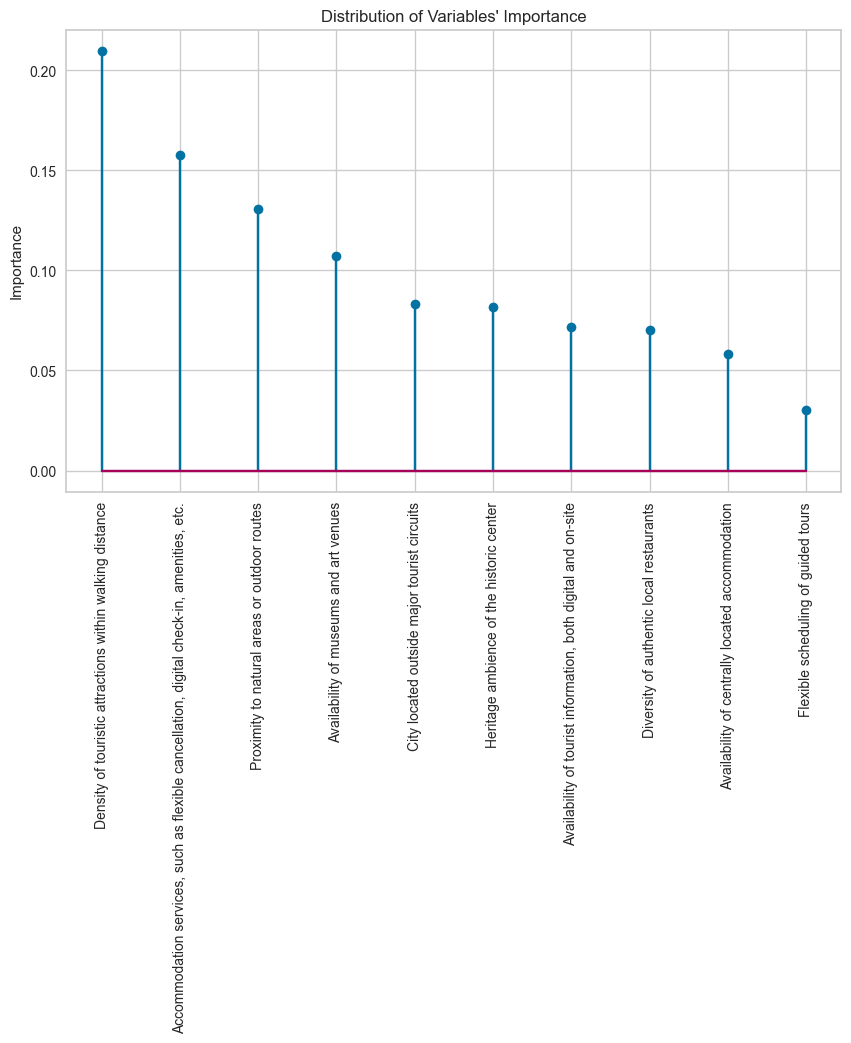

In [1442]:
plt.figure(figsize=(10, 6))
plt.stem(importances["Importance"])
plt.xticks(range(len(importances)), importances.index, rotation=90)
plt.title("Distribution of Variables' Importance")
plt.ylabel("Importance")
plt.show()

# Van Westendorp

## Function

In [1443]:
# Function to calculate intersection points between two curves
def find_intersection(x1, y1, x2, y2):
    # Interpolate both curves onto a common x-axis grid
    common_x = np.linspace(max(min(x1), min(x2)), min(max(x1), max(x2)), 500)
    y1_interp = np.interp(common_x, x1, y1)
    y2_interp = np.interp(common_x, x2, y2)

    # Calculate the difference between the two curves
    diff = y1_interp - y2_interp
    sign_change = np.where(np.diff(np.sign(diff)))[0]  # Detect zero-crossing

    # Calculate intersections
    intersections = []
    for idx in sign_change:
        x_intersect = np.interp(0, [diff[idx], diff[idx + 1]], [common_x[idx], common_x[idx + 1]])
        y_intersect = np.interp(x_intersect, x1, y1)  # Use one curve for the y-value
        intersections.append((x_intersect, y_intersect))
    return intersections

# Van Westendorp analysis function (no product_name)
def van_westendorp_analysis(df):
    # Extract the relevant columns
    too_cheap = df['too_cheap']
    cheap = df['cheap']
    expensive = df['expensive']
    too_expensive = df['too_expensive']

    # Function to calculate cumulative percentages
    def calculate_cumulative_percent(series, invert=False):
        sorted_series = np.sort(series)
        cum_percent = np.arange(1, len(sorted_series) + 1) / len(sorted_series) * 100
        if invert:
            cum_percent = 100 - cum_percent
        return sorted_series, cum_percent

    # Calculate cumulative percentages
    too_cheap_sorted, too_cheap_cum = calculate_cumulative_percent(too_cheap, invert=True)
    cheap_sorted, cheap_cum = calculate_cumulative_percent(cheap, invert=True)
    expensive_sorted, expensive_cum = calculate_cumulative_percent(expensive)
    too_expensive_sorted, too_expensive_cum = calculate_cumulative_percent(too_expensive)

    # Find intersections
    marginal_cheapness = find_intersection(too_cheap_sorted, too_cheap_cum, expensive_sorted, expensive_cum)
    marginal_expensiveness = find_intersection(too_expensive_sorted, too_expensive_cum, cheap_sorted, cheap_cum)
    indifference_price_point = find_intersection(cheap_sorted, cheap_cum, expensive_sorted, expensive_cum)
    optimal_price_point = find_intersection(too_cheap_sorted, too_cheap_cum, too_expensive_sorted, too_expensive_cum)

    # Extract specific x-values for range of acceptable prices
    x_marginal_cheapness = marginal_cheapness[0][0] if marginal_cheapness else None
    x_marginal_expensiveness = marginal_expensiveness[0][0] if marginal_expensiveness else None

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.plot(too_cheap_sorted, too_cheap_cum, label='Too Cheap', color='orange')
    plt.plot(cheap_sorted, cheap_cum, label='Cheap', color='green')
    plt.plot(expensive_sorted, expensive_cum, label='Expensive', color='blue')
    plt.plot(too_expensive_sorted, too_expensive_cum, label='Too Expensive', color='red')

    # Mark intersection points with labels
    for x, y in marginal_cheapness:
        plt.scatter(x, y, color='purple', label=f'Point of Marginal Cheapness ({x:.2f})')
    for x, y in marginal_expensiveness:
        plt.scatter(x, y, color='brown', label=f'Point of Marginal Expensiveness ({x:.2f})')
    for x, y in indifference_price_point:
        plt.scatter(x, y, color='blue', label=f'Indifference Price Point ({x:.2f})')
    for x, y in optimal_price_point:
        plt.scatter(x, y, color='green', label=f'Optimal Price Point ({x:.2f})')

    # Draw vertical lines and label the range of acceptable prices
    if x_marginal_cheapness and x_marginal_expensiveness:
        plt.axvline(x=x_marginal_cheapness, color='purple', linestyle='--', label='Point of Marginal Cheapness')
        plt.axvline(x=x_marginal_expensiveness, color='brown', linestyle='--', label='Point of Marginal Expensiveness')
        plt.fill_betweenx([0, 100], x_marginal_cheapness, x_marginal_expensiveness, color='gray', alpha=0.3, label='Range of Acceptable Prices')

    plt.title("Van Westendorp Price Sensitivity Meter")
    plt.xlabel("Price")
    plt.ylabel("Cumulative Percentage (%)")
    plt.legend()
    plt.grid()
    plt.show()

    # Report only x-values
    print("Van Westendorp Analysis:")
    print(f"Point of Marginal Cheapness: {x_marginal_cheapness:.2f}" if x_marginal_cheapness else "Point of Marginal Cheapness: Not found")
    print(f"Point of Marginal Expensiveness: {x_marginal_expensiveness:.2f}" if x_marginal_expensiveness else "Point of Marginal Expensiveness: Not found")
    print(f"Indifference Price Point: {indifference_price_point[0][0]:.2f}" if indifference_price_point else "Indifference Price Point: Not found")
    print(f"Optimal Price Point: {optimal_price_point[0][0]:.2f}" if optimal_price_point else "Optimal Price Point: Not found")
    print("\n")

## Analysis

In [1444]:
df_vw = df[["too_cheap", "cheap", "expensive", "too_expensive"]]
df_vw["cluster"] = df_clustering["cluster"]

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\2884293522.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vw["cluster"] = df_clustering["cluster"]


In [1445]:
len(df_vw)

125

In [1446]:
# Remove ilogic cases

df_vw = df_vw[
    (df_vw['too_cheap'] <= df_vw['cheap']) &
    (df_vw['cheap'] <= df_vw['expensive']) &
    (df_vw['expensive'] <= df_vw['too_expensive'])
]

In [1447]:
len(df_vw)

95

In [1448]:
# Inter Quartile Range
Q1 = df_vw.quantile(0.25)
Q3 = df_vw.quantile(0.75)
IQR = Q3 - Q1

# Filtering
mask = ~(
    (df_vw < (Q1 - 1.5 * IQR)) |
    (df_vw > (Q3 + 1.5 * IQR))
).any(axis=1)

# New dataset
df_vw_clean = df_vw[mask]

In [1449]:
len(df_vw_clean)

83

In [1450]:
# Remove impossible prices (this is a good improvement i future surveys)

df_vw_clean = df_vw_clean[df_vw_clean['too_cheap'] >= 50]

len(df_vw_clean)

71

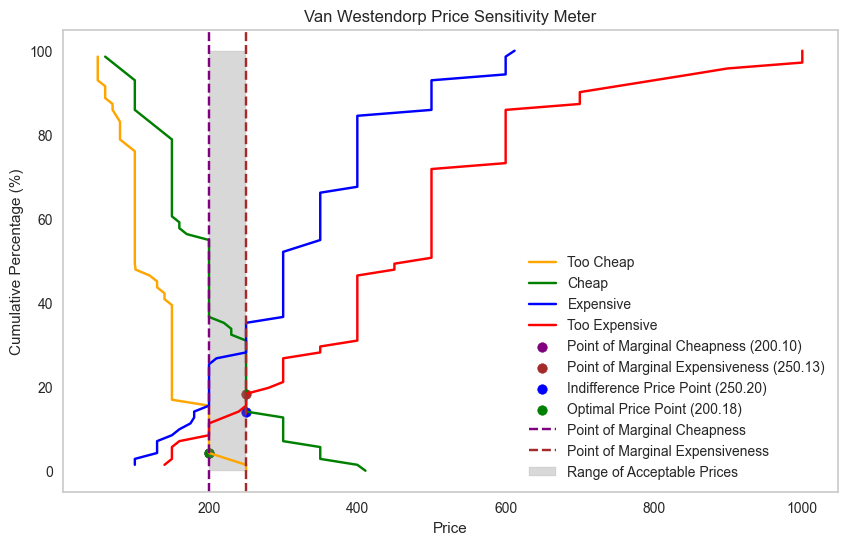

Van Westendorp Analysis:
Point of Marginal Cheapness: 200.10
Point of Marginal Expensiveness: 250.13
Indifference Price Point: 250.20
Optimal Price Point: 200.18




In [1451]:
van_westendorp_analysis(df_vw_clean)

### Cluster 1

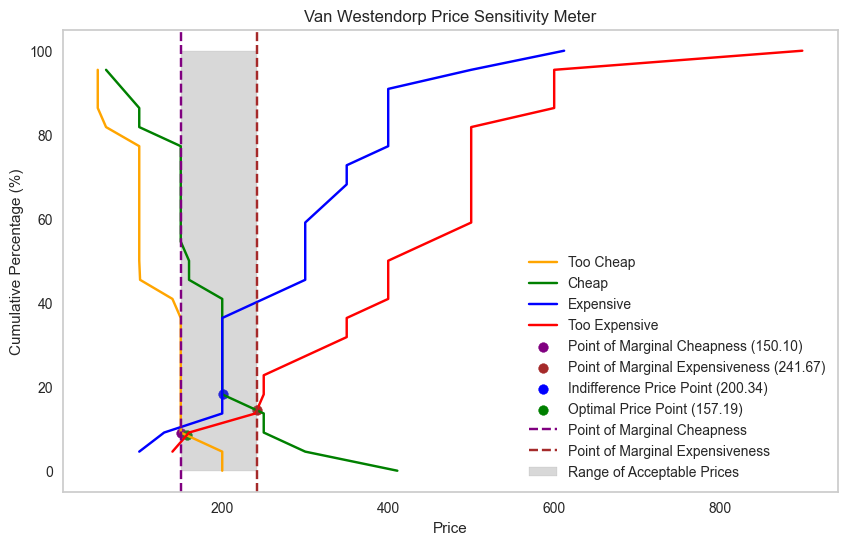

Van Westendorp Analysis:
Point of Marginal Cheapness: 150.10
Point of Marginal Expensiveness: 241.67
Indifference Price Point: 200.34
Optimal Price Point: 157.19




In [1452]:
cluster_1 = df_vw_clean[df_vw_clean['cluster'] == 1]
van_westendorp_analysis(cluster_1)

In [1453]:
cluster_1.describe()

,too_cheap,cheap,expensive,too_expensive,cluster
count,22.000000,22.000000,22.000000,22.000000,22.0
mean,118.227273,180.500000,300.772727,426.772727,1.0
std,44.127447,76.642491,122.349200,172.727678,0.0
min,50.000000,60.000000,100.000000,140.000000,1.0
25%,100.000000,150.000000,200.000000,312.500000,1.0
50%,100.500000,160.000000,300.000000,425.000000,1.0
75%,150.000000,200.000000,387.500000,500.000000,1.0
max,200.000000,411.000000,612.000000,899.000000,1.0


### Cluste 2

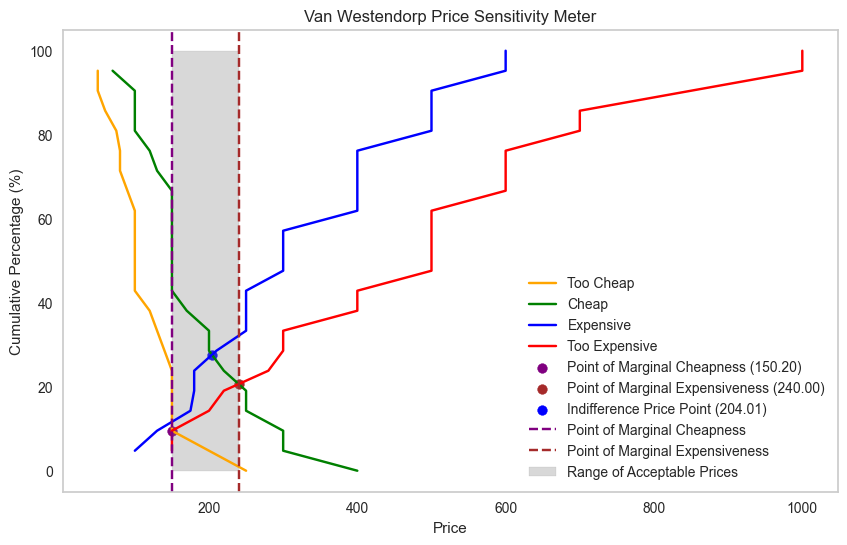

Van Westendorp Analysis:
Point of Marginal Cheapness: 150.20
Point of Marginal Expensiveness: 240.00
Indifference Price Point: 204.01
Optimal Price Point: Not found




In [1454]:
cluster_2 = df_vw_clean[df_vw_clean['cluster'] == 2]
van_westendorp_analysis(cluster_2)

In [1455]:
cluster_2.describe()

,too_cheap,cheap,expensive,too_expensive,cluster
count,21.000000,21.000000,21.000000,21.000000,21.0
mean,115.476190,181.428571,329.761905,497.619048,2.0
std,49.241871,81.319476,150.053959,254.379731,0.0
min,50.000000,70.000000,100.000000,150.000000,2.0
25%,80.000000,130.000000,210.000000,300.000000,2.0
50%,100.000000,150.000000,300.000000,500.000000,2.0
75%,150.000000,220.000000,400.000000,600.000000,2.0
max,250.000000,400.000000,600.000000,1000.000000,2.0


### Cluster 3

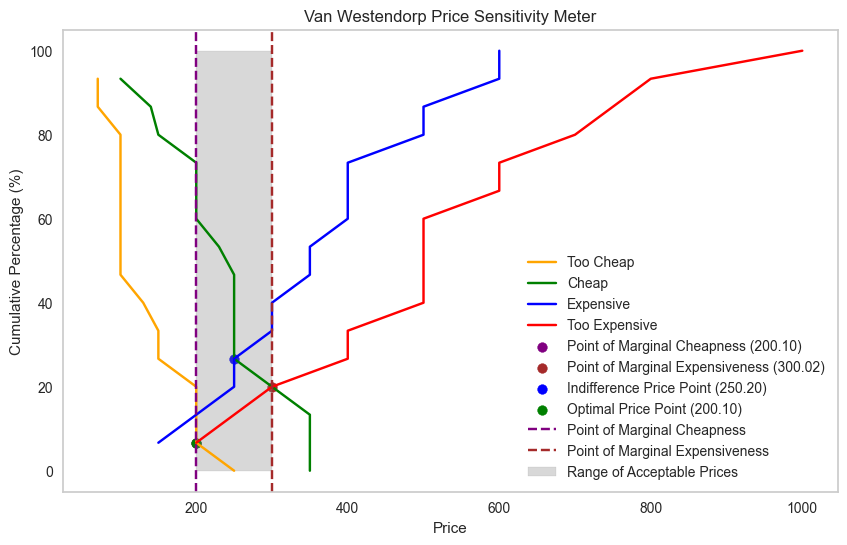

Van Westendorp Analysis:
Point of Marginal Cheapness: 200.10
Point of Marginal Expensiveness: 300.02
Indifference Price Point: 250.20
Optimal Price Point: 200.10




In [1456]:
cluster_3 = df_vw_clean[df_vw_clean['cluster'] == 3]
van_westendorp_analysis(cluster_3)

In [1457]:
cluster_3.describe()

,too_cheap,cheap,expensive,too_expensive,cluster
count,15.000000,15.000000,15.000000,15.000000,15.0
mean,134.666667,238.000000,370.000000,533.333333,3.0
std,54.885161,76.922967,136.014705,216.849740,0.0
min,70.000000,100.000000,150.000000,200.000000,3.0
25%,100.000000,200.000000,275.000000,400.000000,3.0
50%,100.000000,250.000000,350.000000,500.000000,3.0
75%,175.000000,275.000000,450.000000,650.000000,3.0
max,250.000000,350.000000,600.000000,1000.000000,3.0


### Cluster 4

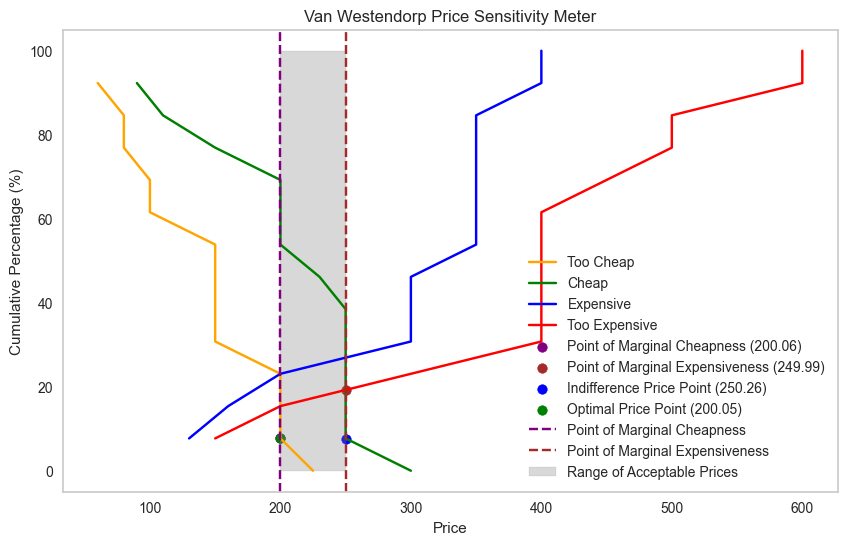

Van Westendorp Analysis:
Point of Marginal Cheapness: 200.06
Point of Marginal Expensiveness: 249.99
Indifference Price Point: 250.26
Optimal Price Point: 200.05




In [1458]:
cluster_4 = df_vw_clean[df_vw_clean['cluster'] == 4]
van_westendorp_analysis(cluster_4)

In [1459]:
cluster_4.describe()

,too_cheap,cheap,expensive,too_expensive,cluster
count,13.000000,13.000000,13.000000,13.000000,13.0
mean,141.923077,210.000000,303.076923,407.692308,4.0
std,54.142500,61.101009,87.023427,133.613488,0.0
min,60.000000,90.000000,130.000000,150.000000,4.0
25%,100.000000,200.000000,300.000000,400.000000,4.0
50%,150.000000,230.000000,350.000000,400.000000,4.0
75%,200.000000,250.000000,350.000000,500.000000,4.0
max,225.000000,300.000000,400.000000,600.000000,4.0


# Predictive Model

In [1460]:
import statsmodels.formula.api as smf

## Data preparation

In [1461]:
df_predictive_model = df[['define_accommodation', 'accommodation_search', 'less_crowded_willingness', 'extra_travel_time',
                          'city_tour_type', 'architectural_interest', 'eating_preference',
                          'restaurant_choice', 'natural_environment_type', 'age_group', 'gender', 'residence', 'occupation']]

In [1462]:
df['city_tour_type'].unique()

array(['Tourist train (Tren turístico)',
       'Guided walking tour (Tour guiado a pie)',
       'Private tour (Tour privado)', nan,
       'Guided bicycle tour\xa0(Tour guiado en bicicleta)'], dtype=object)

In [1463]:
df_predictive_model['define_accommodation'] = df_predictive_model['define_accommodation'].replace({
    "…book in advance during the planning phase (reservar con tiempo durante la planificación)": 1,
    "…book at the last minute (reservar a último momento)": 2,
    "…book directly at the destination (reservar directamente en destino)": 3})

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\3256519308.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_predictive_model['define_accommodation'] = df_predictive_model['define_accommodation'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_12100\3256519308.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predictive_model['define_accommodation'] = df_predictive_model['define_accommodation'].replace({


In [1464]:
# Replace time with average of the range
df_predictive_model['extra_travel_time'] = df_predictive_model['extra_travel_time'].replace({
    "Up to 30 minutes (Hasta 30 minutos)": 0.5,
    "1–2 hours (1-2 horas)": 1.5,
    "3–4 hours (3-4 horas)": 3.5,
    "More than 4 hours (Más de 4 horas)": 4.5,
    "I wouldn’t travel longer for that reason (No viajaría más por esa razón)": 0})

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\2522929736.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_predictive_model['extra_travel_time'] = df_predictive_model['extra_travel_time'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_12100\2522929736.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predictive_model['extra_travel_time'] = df_predictive_model['extra_travel_time'].replace({


In [1465]:
# Replace city tour with numbers
df_predictive_model['city_tour_type'] = df_predictive_model['city_tour_type'].replace({
    "Guided walking tour (Tour guiado a pie)": 1,
    "Private tour (Tour privado)": 2,
    "Guided bicycle tour\xa0(Tour guiado en bicicleta)": 3,
    "Tourist train (Tren turístico)": 4,
    "": 0})

df_predictive_model['city_tour_type'] = df_predictive_model['city_tour_type'].fillna(0)

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\376882784.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_predictive_model['city_tour_type'] = df_predictive_model['city_tour_type'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_12100\376882784.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predictive_model['city_tour_type'] = df_predictive_model['city_tour_type'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_12100\376882784.py:9: SettingWithCopyWarning: 
A value is trying to be set on a 

In [1466]:
# Replace eating preferences with numbers
df_predictive_model['eating_preference'] = df_predictive_model['eating_preference'].replace({
    "In the historic center (En el centro histórico)": 1,
    "Near my accommodation\xa0(Cerca de mi alojamiento)": 2,
    "In tourist areas (En zonas turísticas)": 3,
    "In less crowded, local neighborhoods (En barrios locales menos concurridos)": 4,
    "It doesn’t matter to me (Me da lo mismo)": 0,
    "": 0})

df_predictive_model['eating_preference'] = df_predictive_model['eating_preference'].fillna(0)

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\4007510096.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_predictive_model['eating_preference'] = df_predictive_model['eating_preference'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_12100\4007510096.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predictive_model['eating_preference'] = df_predictive_model['eating_preference'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_12100\4007510096.py:10: SettingWithCopyWarning: 
A value is trying

In [1467]:
# Replace age groups with numbers
df_predictive_model['age_group'] = df_predictive_model['age_group'].replace({
    "<18": 1,
    "18-25": 2,
    "26-35": 3,
    "36-45": 4,
    "46-55": 5,
    ">55": 6})

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\2922305425.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_predictive_model['age_group'] = df_predictive_model['age_group'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_12100\2922305425.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predictive_model['age_group'] = df_predictive_model['age_group'].replace({


In [1468]:
# Replace gender with number
df_predictive_model['gender'] = df_predictive_model['gender'].replace({
    "Male (Masculino)": 1,
    "Female (Femenino)": 0})

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\983272949.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_predictive_model['gender'] = df_predictive_model['gender'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_12100\983272949.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predictive_model['gender'] = df_predictive_model['gender'].replace({


In [1469]:
# Replace residence with numbers

df_predictive_model['residence'] = df_predictive_model['residence'].replace({
    "Italy (Italia)": 1,
    "Europe, excluding Italy\xa0(Europa, sin contar Italia)": 2,
    "Asia": 3,
    "Africa": 4,
    "Oceania": 5,
    "North America (América del Norte)": 6,
    "Central America (América Central)": 7,
    "South America (América del Sur)": 8})

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\3557247347.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_predictive_model['residence'] = df_predictive_model['residence'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_12100\3557247347.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predictive_model['residence'] = df_predictive_model['residence'].replace({


In [1470]:
# Replace occupation with numbers
df_predictive_model['occupation'] = df_predictive_model['occupation'].replace({
    "Employed\xa0(Empleado/a)": 1,
    "Self-employed (Independiente)": 2,
    "Student (Estudiante)": 3,
    "Retired (Jubilado)": 4,
    "Unemployed\xa0(Desempleado)": 5})

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\3069216393.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_predictive_model['occupation'] = df_predictive_model['occupation'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_12100\3069216393.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predictive_model['occupation'] = df_predictive_model['occupation'].replace({


In [1471]:
# Separate answers into columns

def mult_answers(row):
    option = [a.strip() for a in str(row).split(";") if a.strip()]
    return {a: 1 for a in option}

def answer_title(df, column_name):
    expanded = df[column_name].apply(mult_answers)
    expanded = pd.DataFrame(expanded.tolist()).fillna(0).astype(int)
    expanded.columns = [f"{col} ({column_name})" for col in expanded.columns]
    return expanded

# Accommodation Search
accommodation_search = answer_title(df_predictive_model, "accommodation_search")

# No City Tour
architectural_interest = answer_title(df_predictive_model, "architectural_interest")

# restaurant_choice
restaurant_choice = answer_title(df_predictive_model, "restaurant_choice")

# natural_environment_type
natural_environment_type = answer_title(df_predictive_model, "natural_environment_type")

# Drop original columns
df_predictive_model = df_predictive_model.drop(columns=["accommodation_search", "architectural_interest", "restaurant_choice",
                                                        "natural_environment_type"])

In [1472]:
df_predictive_model = pd.concat([
    df_predictive_model,
    accommodation_search,
    architectural_interest,
    restaurant_choice,
    natural_environment_type
], axis=1)

In [1473]:
# Adding clusters

df_predictive_model["cluster"] = df_clustering["cluster"]

In [1474]:
# Drop useless column

df_predictive_model = df_predictive_model.drop(columns=["nan (architectural_interest)"])

In [1475]:
df_predictive_model.to_excel("table_for_predictive.xlsx")

## Manipulation & Testing

In [1476]:
df_predictive_model.columns = [
    "define_accommodation",
    "less_crowded_willingness",
    "extra_travel_time",
    "city_tour_type",
    "eating_preference",
    "age_group",
    "gender",
    "residence",
    "occupation",
    "Booking (accommodation_search)",
    "Airbnb (accommodation_search)",
    "Google (accommodation_search)",
    "Hotels (accommodation_search)",
    "Travel agencies (accommodation_search)",
    "Personal recommendation (accommodation_search)",
    "Social media (accommodation_search)",
    "ChatGPT and google maps (accommodation_search)",
    "Medieval architecture (architectural_interest)",
    "Historical squares and public spaces (architectural_interest)",
    "Museums and cultural centers (architectural_interest)",
    "Renaissance and Baroque palaces (architectural_interest)",
    "Religious buildings (architectural_interest)",
    "Modern or contemporary architecture (architectural_interest)",
    "I decide while walking by (restaurant_choice)",
    "Based on personal recommendations (restaurant_choice)",
    "Based on online reviews (restaurant_choice)",
    "Based on location (restaurant_choice)",
    "I search and book in advance (restaurant_choice)",
    "Based on recommendations I see on social media (restaurant_choice)",
    "I look for specific experiences or foods (restaurant_choice)",
    "Michelin Guide (restaurant_choice)",
    "Beach (natural_environment_type)",
    "Natural parks (natural_environment_type)",
    "Mountains (natural_environment_type)",
    "Lake/Rivers (natural_environment_type)",
    "El mar, pero no necesariamente playa (natural_environment_type)",
    "Cities with históricas heritage (natural_environment_type)",
    "cluster"
]

In [1477]:
# Group other answers, as they are not too much
def combine_columns(df, new_name, cols):
    df[new_name] = df[cols].max(axis=1).astype(int)
    df.drop(columns=cols, inplace=True)

# accommodation_search search
combine_columns(df_predictive_model,"Others (accommodation_search)", ["ChatGPT and google maps (accommodation_search)"])

# restaurant_choice
combine_columns(df_predictive_model,"Others (restaurant_choice)",
    [
        "Based on recommendations I see on social media (restaurant_choice)",
        "I look for specific experiences or foods (restaurant_choice)",
        "Michelin Guide (restaurant_choice)"
    ]
)

# natural_environment_type
combine_columns(df_predictive_model,"Others (natural_environment_type)",
    [
        "El mar, pero no necesariamente playa (natural_environment_type)",
        "Cities with históricas heritage (natural_environment_type)"
    ]
)

In [1478]:
# Group Accommodation Search

# Crear columna digital_platforms
df_predictive_model['digital_platforms (accommodation_search)'] = (
    df_predictive_model['Booking (accommodation_search)'] +
    df_predictive_model['Airbnb (accommodation_search)'] +
    df_predictive_model['Social media (accommodation_search)']
).apply(lambda x: 1 if x > 0 else 0)

# Crear columna traditional_channels
df_predictive_model['traditional_channels (accommodation_search)'] = (
    df_predictive_model['Google (accommodation_search)'] +
    df_predictive_model['Hotels (accommodation_search)'] +
    df_predictive_model['Travel agencies (accommodation_search)'] +
    df_predictive_model['Personal recommendation (accommodation_search)']
).apply(lambda x: 1 if x > 0 else 0)

# Drop original ones
cols_to_drop = [
    "Booking (accommodation_search)",
    "Airbnb (accommodation_search)",
    "Google (accommodation_search)",
    "Hotels (accommodation_search)",
    "Travel agencies (accommodation_search)",
    "Personal recommendation (accommodation_search)",
    "Social media (accommodation_search)"
]

df_predictive_model = df_predictive_model.drop(columns=cols_to_drop)

In [1479]:
# Group Architectural Interest

# Historical Architecture
df_predictive_model['historical_architecture (architectural_interest)'] = (
    df_predictive_model['Medieval architecture (architectural_interest)'] +
    df_predictive_model['Renaissance and Baroque palaces (architectural_interest)'] +
    df_predictive_model['Religious buildings (architectural_interest)'] +
    df_predictive_model['Historical squares and public spaces (architectural_interest)']
).apply(lambda x: 1 if x > 0 else 0)

# Cultural Institutions
df_predictive_model['contemporary_cultural_interest (architectural_interest)'] = (
    df_predictive_model['Museums and cultural centers (architectural_interest)']+
    df_predictive_model['Modern or contemporary architecture (architectural_interest)']
).apply(lambda x: 1 if x > 0 else 0)

# Drop original columns
cols_to_drop = [
    "Medieval architecture (architectural_interest)",
    "Historical squares and public spaces (architectural_interest)",
    "Museums and cultural centers (architectural_interest)",
    "Renaissance and Baroque palaces (architectural_interest)",
    "Religious buildings (architectural_interest)",
    "Modern or contemporary architecture (architectural_interest)"
]

df_predictive_model = df_predictive_model.drop(columns=cols_to_drop)

In [1480]:
# Restaurant Chocie

# Personal Choice
df_predictive_model['personal_choice (restaurant_choice)'] = (
    df_predictive_model['I decide while walking by (restaurant_choice)'] +
    df_predictive_model['Based on location (restaurant_choice)'] +
    df_predictive_model['I search and book in advance (restaurant_choice)']
).apply(lambda x: 1 if x > 0 else 0)

# Social Influence
df_predictive_model['social_influence (restaurant_choice)'] = (
    df_predictive_model['Based on personal recommendations (restaurant_choice)'] +
    df_predictive_model['Based on online reviews (restaurant_choice)']
).apply(lambda x: 1 if x > 0 else 0)

# Drop original columns

cols_to_drop = [
    "I decide while walking by (restaurant_choice)",
    "Based on personal recommendations (restaurant_choice)",
    "Based on online reviews (restaurant_choice)",
    "Based on location (restaurant_choice)",
    "I search and book in advance (restaurant_choice)"
]

df_predictive_model = df_predictive_model.drop(columns=cols_to_drop)

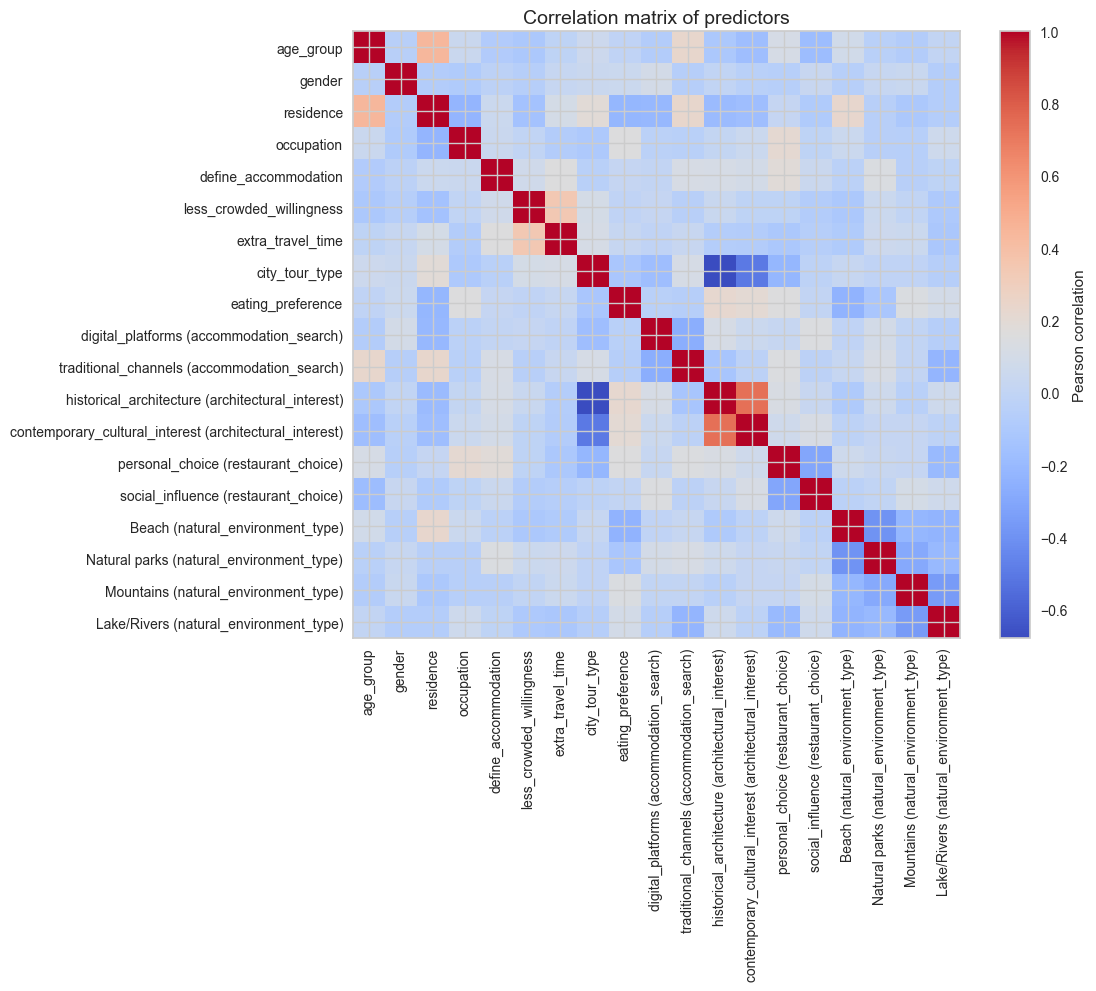

In [1481]:
# Check multicolineality

variables = [
    "age_group",
    "gender",
    "residence",
    "occupation",
    "define_accommodation",
    "less_crowded_willingness",
    "extra_travel_time",
    "city_tour_type",
    "eating_preference",
    "digital_platforms (accommodation_search)",
    "traditional_channels (accommodation_search)",
    "historical_architecture (architectural_interest)",
    "contemporary_cultural_interest (architectural_interest)",
    "personal_choice (restaurant_choice)",
    "social_influence (restaurant_choice)",
    "Beach (natural_environment_type)",
    "Natural parks (natural_environment_type)",
    "Mountains (natural_environment_type)",
    "Lake/Rivers (natural_environment_type)"
]

corr = df_predictive_model[variables].corr()

plt.figure(figsize=(12, 10))
plt.title("Correlation matrix of predictors", fontsize=14)
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Pearson correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

In [1482]:
high_corr = corr[(corr.abs() > 0.7) & (corr.abs() < 1)]
high_corr.dropna(how='all', inplace=True)
high_corr

,age_group,gender,residence,occupation,define_accommodation,less_crowded_willingness,extra_travel_time,city_tour_type,eating_preference,digital_platforms (accommodation_search),traditional_channels (accommodation_search),historical_architecture (architectural_interest),contemporary_cultural_interest (architectural_interest),personal_choice (restaurant_choice),social_influence (restaurant_choice),Beach (natural_environment_type),Natural parks (natural_environment_type),Mountains (natural_environment_type),Lake/Rivers (natural_environment_type)
historical_architecture (architectural_interest),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.735147,NaN,NaN,NaN,NaN,NaN,NaN
contemporary_cultural_interest (architectural_interest),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.735147,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1483]:
high_corr = corr[(corr.abs() < -0.7) & (corr.abs() > -1)]
high_corr.dropna(how='all', inplace=True)
high_corr

,age_group,gender,residence,occupation,define_accommodation,less_crowded_willingness,extra_travel_time,city_tour_type,eating_preference,digital_platforms (accommodation_search),traditional_channels (accommodation_search),historical_architecture (architectural_interest),contemporary_cultural_interest (architectural_interest),personal_choice (restaurant_choice),social_influence (restaurant_choice),Beach (natural_environment_type),Natural parks (natural_environment_type),Mountains (natural_environment_type),Lake/Rivers (natural_environment_type)


There is collineality between historical_architecture (architectural_interest) and contemporary_cultural_interest (architectural_interest), so we will leave the first one. 

In [1484]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_predictive_model[variables].assign(const=1)
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif.sort_values(by="VIF", ascending=False)

,Variable,VIF
19,const,96.218293
11,historical_architecture (architectural_interest),3.385057
15,Beach (natural_environment_type),2.622538
16,Natural parks (natural_environment_type),2.590555
18,Lake/Rivers (natural_environment_type),2.477505
17,Mountains (natural_environment_type),2.428294
12,contemporary_cultural_interest (architectural_...,2.376164
7,city_tour_type,2.124081
2,residence,1.677343
13,personal_choice (restaurant_choice),1.448941


historical_architecture (architectural_interest) is removed to avoid colineality.

In [1485]:
formula = """
cluster ~ age_group
+ gender
+ residence
+ occupation
+ define_accommodation
+ less_crowded_willingness
+ extra_travel_time
+ city_tour_type
+ eating_preference
+ Q("digital_platforms (accommodation_search)")
+ Q("traditional_channels (accommodation_search)")
+ Q("historical_architecture (architectural_interest)")
+ Q("contemporary_cultural_interest (architectural_interest)")
+ Q("personal_choice (restaurant_choice)")
+ Q("social_influence (restaurant_choice)")
+ Q("Beach (natural_environment_type)")
+ Q("Natural parks (natural_environment_type)")
+ Q("Mountains (natural_environment_type)")
+ Q("Lake/Rivers (natural_environment_type)")
"""

In [1486]:
model = smf.mnlogit(formula=formula, data=df_predictive_model).fit()
model.summary()

         Current function value: 1.063160
         Iterations: 35


c:\Users\franc\Documents\GitHub\DSE_thesis\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:                cluster   No. Observations:                  125
Model:                        MNLogit   Df Residuals:                       65
Method:                           MLE   Df Model:                           57
Date:                Sat, 25 Oct 2025   Pseudo R-squ.:                  0.2252
Time:                        18:36:21   Log-Likelihood:                -132.89
converged:                      False   LL-Null:                       -171.53
Covariance Type:            nonrobust   LLR p-value:                   0.03827
================================================================================================================================
                                                   cluster=2       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------
Intercept                                                        4.2522      2.975      1.429      0.153      -1.579      10.083
age_group                                                       -0.1870      0.257     -0.726      0.468      -0.692       0.318
gender                                                           1.3889      0.586      2.370      0.018       0.240       2.537
residence                                                       -0.3376      0.111     -3.045      0.002      -0.555      -0.120
occupation                                                      -0.0049      0.304     -0.016      0.987      -0.601       0.591
define_accommodation                                            -0.8900      0.911     -0.977      0.329      -2.676       0.896
less_crowded_willingness                                        -0.1643      0.292     -0.562      0.574      -0.737       0.409
extra_travel_time                                               -0.1937      0.239     -0.811      0.417      -0.662       0.274
city_tour_type                                                   0.1617      0.403      0.401      0.688      -0.628       0.952
eating_preference                                                0.0422      0.184      0.229      0.819      -0.318       0.402
Q("digital_platforms (accommodation_search)")                   -0.6448      1.139     -0.566      0.571      -2.876       1.587
Q("traditional_channels (accommodation_search)")                -0.2039      0.644     -0.317      0.752      -1.466       1.058
Q("historical_architecture (architectural_interest)")            0.8533      1.119      0.762      0.446      -1.340       3.047
Q("contemporary_cultural_interest (architectural_interest)")    -0.4693      1.175     -0.400      0.689      -2.772       1.833
Q("personal_choice (restaurant_choice)")                         0.1381      0.741      0.186      0.852      -1.314       1.590
Q("social_influence (restaurant_choice)")                       -0.4400      0.756     -0.582      0.561      -1.923       1.043
Q("Beach (natural_environment_type)")                            0.6478      0.991      0.654      0.513      -1.294       2.590
Q("Natural parks (natural_environment_type)")                   -0.7614      0.937     -0.812      0.417      -2.598       1.076
Q("Mountains (natural_environment_type)")                       -0.7647      0.866     -0.883      0.377      -2.462       0.933
Q("Lake/Rivers (natural_environment_type)")                     -0.7073      0.933     -0.758      0.448      -2.536       1.122
--------------------------------------------------------------------------------------------------------------------------------
                                                   cluster=3       coef    std err          z      P>|z|      [0.025      0.975]
----------------

After the first run of the model, some variables will be remvoed, as the model contains too many variables:

- define_accommodation: Displayed extremely large standard errors and unstable coefficients, indicating overfitting and poor estimation reliability.
- less_crowded_willingness: Showed no significant contribution to any cluster (p ≫ 0.10).
- extra_travel_time: Coefficients were small and statistically insignificant across all clusters.
- eating_preference: Produced negligible effects and very low magnitude estimates.
- historical_architecture (architectural_interest): Although both represent aspects of cultural engagement, the contemporary dimension demonstrated greater variability across clusters and a near-significant coefficient (p ≈ 0.07), suggesting it better discriminates between tourist profiles. In contrast, historical architecture yielded uniformly non-significant effects and large confidence intervals, indicating that appreciation of historical heritage is a shared baseline among respondents rather than a differentiating factor. Including the contemporary cultural dimension improved overall model fit and convergence.
- personal_choice (restaurant_choice) and social_influence (restaurant_choice): Both variables exhibited consistently high p-values and no meaningful differentiation among clusters, suggesting that restaurant decision motives do not influence overall segmentation.
- natural_environment_type: Despite theoretical relevance, these variables displayed large uncertainty.

The variables included in the final model were selected because:
+ age_group: remained in the model as it exhibited statistically significant effects (p < 0.05) in at least one cluster, confirming the influence of age on tourist segmentation.
+ gender: consistently significant (p ≈ 0.02–0.04) across multiple clusters, providing a robust demographic discriminator.
+ residence: despite being excluded in preliminary runs, it became statistically significant (p < 0.05) in the optimized model, capturing geographical variation among respondents.
+ occupation: although not always statistically significant, this variable was retained for its socioeconomic interpretive value and contribution to model structure.
+ city_tour_type: included to represent behavioral preferences, even if not significant in all clusters, as it adds conceptual completeness to the segmentation model.
+ digital_platforms (accommodation_search) and traditional_channels (accommodation_search): retained to contrast digital and traditional booking behaviors; while effects were not consistently significant, their inclusion allows for behavioral profiling of travelers.
+ contemporary_cultural_interest (architectural_interest): maintained due to its near-significant effect (p ≈ 0.07) and its theoretical importance in explaining culture-oriented travel motivations.

In [1487]:
formula = """
cluster ~ age_group
+ gender
+ residence
+ occupation
+ city_tour_type
+ Q("digital_platforms (accommodation_search)")
+ Q("traditional_channels (accommodation_search)")
+ Q("contemporary_cultural_interest (architectural_interest)")
""" 

In [1488]:
model = smf.mnlogit(formula=formula, data=df_predictive_model).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 1.220667
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:                cluster   No. Observations:                  125
Model:                        MNLogit   Df Residuals:                       98
Method:                           MLE   Df Model:                           24
Date:                Sat, 25 Oct 2025   Pseudo R-squ.:                  0.1104
Time:                        18:36:21   Log-Likelihood:                -152.58
converged:                       True   LL-Null:                       -171.53
Covariance Type:            nonrobust   LLR p-value:                   0.03563
================================================================================================================================
                                                   cluster=2       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------
Intercept                                                        1.4212      1.617      0.879      0.380      -1.748       4.591
age_group                                                       -0.0640      0.242     -0.264      0.792      -0.539       0.411
gender                                                           1.2254      0.542      2.262      0.024       0.163       2.287
residence                                                       -0.2761      0.097     -2.838      0.005      -0.467      -0.085
occupation                                                       0.0579      0.272      0.213      0.831      -0.475       0.590
city_tour_type                                                  -0.0946      0.314     -0.301      0.763      -0.710       0.521
Q("digital_platforms (accommodation_search)")                   -0.5241      1.100     -0.477      0.634      -2.679       1.631
Q("traditional_channels (accommodation_search)")                -0.1734      0.569     -0.305      0.761      -1.288       0.942
Q("contemporary_cultural_interest (architectural_interest)")     0.1513      0.868      0.174      0.862      -1.549       1.852
--------------------------------------------------------------------------------------------------------------------------------
                                                   cluster=3       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------
Intercept                                                       -3.0774      1.913     -1.609      0.108      -6.826       0.671
age_group                                                        0.5017      0.253      1.984      0.047       0.006       0.997
gender                                                           0.7213      0.597      1.207      0.227      -0.450       1.892
residence                                                       -0.2159      0.107     -2.027      0.043      -0.425      -0.007
occupation                                                       0.1860      0.287      0.647      0.518      -0.377       0.749
city_tour_type                                                   0.5088      0.318      1.599      0.110      -0.115       1.132
Q("digital_platforms (accommodation_search)")                    0.5086      1.345      0.378      0.705      -2.127       3.144
Q("traditional_channels (accommodation_search)")                -0.3754      0.616     -0.609      0.542      -1.583       0.832
Q("contemporary_cultural_interest (architectural_interest)")     1.6924      0.932      1.815      0.069      -0.135       3.520
--------------------------------------------------------------------------------------------------------------------------------
                

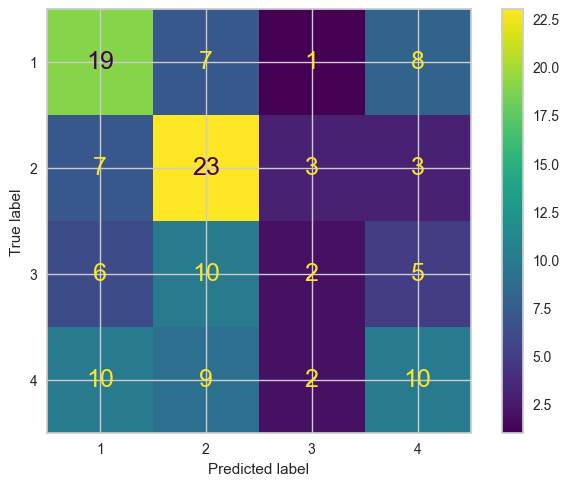

In [1489]:
from sklearn.metrics import ConfusionMatrixDisplay

PredTable = model.pred_table()

ConfusionMatrixDisplay(confusion_matrix=PredTable, display_labels=[1,2,3,4]).plot()

The confusion matrix indicates that the model achieved an overall correct classification rate of approximately 50%. Clusters 1 and 2 were the most accurately predicted, demonstrating clearer internal consistency and stronger differentiation from other groups. Cluster 2, in particular, shows the highest proportion of correct classifications (about 64%), suggesting that its demographic and behavioral features are more distinctive. In contrast, Clusters 3 and 4 exhibit higher levels of overlap, indicating partial similarity in respondent profiles and less sharply defined behavioral boundaries. This outcome is consistent with the exploratory and explanatory purpose of the model, which aims to identify patterns and tendencies rather than achieve perfect classification accuracy.

# Ascoli Piceno Data

## EDA

In [1490]:
df_ascoli = df[['visited_ascoli', 'recommend_ascoli', 'ascoli_likelihood', 'heard_ascoli', 'ascoli_attractiveness']]

df_ascoli['recommend_ascoli'] = df_ascoli['recommend_ascoli'].fillna(0)

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\338832504.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ascoli['recommend_ascoli'] = df_ascoli['recommend_ascoli'].fillna(0)


In [1491]:
df_ascoli['visited_ascoli'] = df['visited_ascoli'].replace({"No": 0, "Yes (Si)": 1})

df_ascoli['heard_ascoli'] = df['heard_ascoli'].replace({"No": 0, "Yes (Si)": 1})

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\972648829.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ascoli['visited_ascoli'] = df['visited_ascoli'].replace({"No": 0, "Yes (Si)": 1})
C:\Users\franc\AppData\Local\Temp\ipykernel_12100\972648829.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ascoli['visited_ascoli'] = df['visited_ascoli'].replace({"No": 0, "Yes (Si)": 1})
C:\Users\franc\AppData\Local\Temp\ipykernel_12100\972648829.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated a

In [1492]:
df_ascoli['ascoli_intent'] = df_ascoli.apply(lambda x: x['recommend_ascoli'] if x['visited_ascoli'] == 1 else x['ascoli_likelihood'],
                                             axis=1)

df_ascoli = df_ascoli.drop(columns=["recommend_ascoli", "ascoli_likelihood"])

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\2043334688.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ascoli['ascoli_intent'] = df_ascoli.apply(lambda x: x['recommend_ascoli'] if x['visited_ascoli'] == 1 else x['ascoli_likelihood'],


In [1493]:
df_ascoli['heard_ascoli'] = df_ascoli['heard_ascoli'].fillna("Nan")

In [1494]:
df_ascoli.head(5)

,visited_ascoli,heard_ascoli,ascoli_attractiveness,ascoli_intent
0,0,0.0,7,10.0
1,0,1.0,6,5.0
2,0,0.0,8,5.0
3,0,0.0,6,6.0
4,0,1.0,2,0.0


In [1495]:
# Compare visited vs not visited

visited = df_ascoli[df_ascoli['visited_ascoli']==1]['ascoli_intent']
not_visited = df_ascoli[df_ascoli['visited_ascoli']==0]['ascoli_intent']

stats.ttest_ind(visited, not_visited, equal_var=False)

TtestResult(statistic=np.float64(3.696731795053412), pvalue=np.float64(0.0012698719261220403), df=np.float64(21.866849337524428))

In [1496]:
# Check correlation

df_ascoli[['ascoli_intent','ascoli_attractiveness','heard_ascoli','visited_ascoli']].corr()

,ascoli_intent,ascoli_attractiveness,heard_ascoli,visited_ascoli
ascoli_intent,1.000000,0.769494,-0.200276,0.279486
ascoli_attractiveness,0.769494,1.000000,-0.273225,0.122324
heard_ascoli,-0.200276,-0.273225,1.000000,NaN
visited_ascoli,0.279486,0.122324,NaN,1.000000


<Axes: >

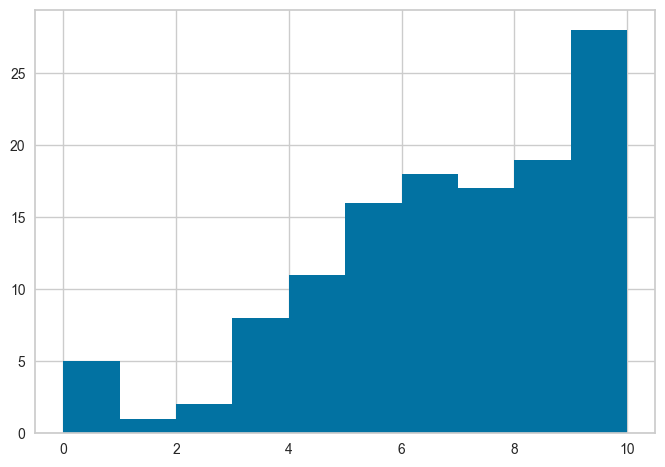

In [1497]:
# Distribution of intent

df_ascoli['ascoli_intent'].hist(bins=10)

<Axes: >

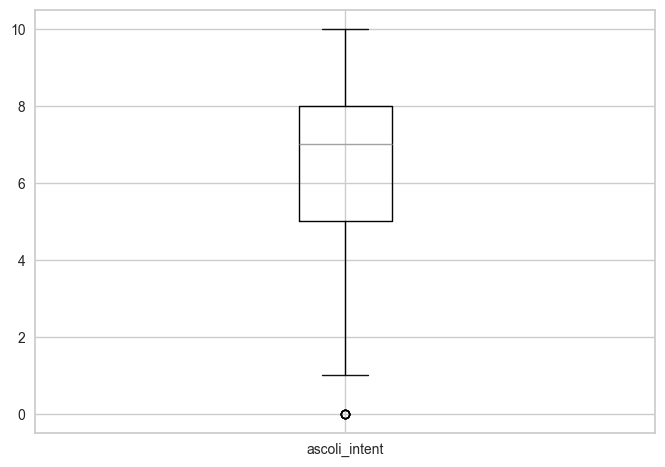

In [1498]:
# Outliers

df_ascoli.boxplot(column='ascoli_intent')


In [1499]:
# Awareness

df_ascoli['heard_ascoli'].value_counts(normalize=True)

heard_ascoli
0.0    0.632
1.0    0.240
Nan    0.128
Name: proportion, dtype: float64

In [1500]:
df_ascoli.describe()

,visited_ascoli,ascoli_attractiveness,ascoli_intent
count,125.000000,125.000000,125.000000
mean,0.128000,7.056000,6.432000
std,0.335434,2.182422,2.588236
min,0.000000,0.000000,0.000000
25%,0.000000,6.000000,5.000000
50%,0.000000,7.000000,7.000000
75%,0.000000,8.000000,8.000000
max,1.000000,10.000000,10.000000


Overall, participants reported moderately positive intentions toward Ascoli Piceno (M = 6.43 on a 0–10 scale) and a generally favorable perception of its attractiveness (M = 7.06). However, prior awareness of the destination was low, with only 24.6% indicating they had heard of Ascoli before the survey. The vast majority of respondents had never visited (12.8% visited), creating a clear distinction between inexperienced and experienced participants.

The correlation analysis shows a strong positive association between perceived attractiveness and intention (r = .77), suggesting that evaluative impressions play an important role in shaping behavioral intentions. Awareness is weakly and negatively correlated with both attractiveness and intention, likely reflecting limited familiarity among respondents.

A histogram and boxplot indicate a reasonable spread of values across the full 0–10 scale, with slight skewness toward higher scores, common in attitudinal tourism data. A small number of low outliers represent genuine low interest rather than measurement error.

Together, these preliminary analyses confirm that the dependent variable is well-distributed, that experience and perception meaningfully influence intentions, and that the dataset is suitable for subsequent regression modeling with attribute rankings and interaction effects.

## Answer by Cluster

In [1501]:
df_ascoli['cluster'] = df_clustering['cluster']

df_ascoli.head(3)

,visited_ascoli,heard_ascoli,ascoli_attractiveness,ascoli_intent,cluster
0,0,0.0,7,10.0,1
1,0,1.0,6,5.0,4
2,0,0.0,8,5.0,1


### Visited Ascoli Piceno

In [1502]:
visited = df_ascoli.groupby('cluster')['visited_ascoli'].mean() * 100

visited.round(2)

cluster
1     8.57
2    19.44
3    13.04
4     9.68
Name: visited_ascoli, dtype: float64

In [1503]:
df_visit = df_ascoli[df_ascoli['visited_ascoli'] == 1]

recommend = df_visit.groupby('cluster')['ascoli_intent'].mean()

recommend

cluster
1    8.000000
2    9.000000
3    6.666667
4    8.666667
Name: ascoli_intent, dtype: float64

In [1504]:
attractiveness_visit = df_visit.groupby('cluster')['ascoli_attractiveness'].mean()

attractiveness_visit

cluster
1    7.333333
2    8.571429
3    6.000000
4    8.000000
Name: ascoli_attractiveness, dtype: float64

### Did Not Visited Ascoli Piceno

In [1505]:
awareness = df_ascoli.groupby('cluster')['heard_ascoli'].apply(lambda x: (x.eq(1).sum() / len(x)) * 100)

awareness.round(2)

cluster
1    25.71
2    30.56
3    26.09
4    12.90
Name: heard_ascoli, dtype: float64

In [1506]:
df_heard = df_ascoli[df_ascoli['heard_ascoli'] == 1]

visit_intent_heard = df_heard.groupby('cluster')['ascoli_intent'].mean()

visit_intent_heard

cluster
1    5.222222
2    4.545455
3    6.666667
4    5.750000
Name: ascoli_intent, dtype: float64

In [1507]:
attractiveness_heard = df_heard.groupby('cluster')['ascoli_attractiveness'].mean()

attractiveness_heard

cluster
1    6.000000
2    5.181818
3    7.333333
4    6.250000
Name: ascoli_attractiveness, dtype: float64

In [1508]:
df_not_heard = df_ascoli[df_ascoli['heard_ascoli'] == 0]

visit_intent_not_heard = df_not_heard.groupby('cluster')['ascoli_intent'].mean()

visit_intent_not_heard

cluster
1    6.217391
2    5.944444
3    7.071429
4    6.750000
Name: ascoli_intent, dtype: float64

In [1509]:
attractiveness_not_heard = df_not_heard.groupby('cluster')['ascoli_attractiveness'].mean()

attractiveness_not_heard

cluster
1    7.173913
2    6.666667
3    7.571429
4    7.791667
Name: ascoli_attractiveness, dtype: float64

# Clusters Description

## Data

In [1510]:
df_descriptors = df[['define_accommodation', 'accommodation_search', 'less_crowded_willingness', 'extra_travel_time',
                          'city_tour_type', 'architectural_interest', 'eating_preference',
                          'restaurant_choice', 'natural_environment_type', 'age_group', 'gender', 'residence', 'occupation']]

df_descriptors["cluster"] = df_clustering["cluster"]

df_descriptors.head(3)

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\1661108865.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_descriptors["cluster"] = df_clustering["cluster"]


,define_accommodation,accommodation_search,less_crowded_willingness,extra_travel_time,city_tour_type,architectural_interest,eating_preference,restaurant_choice,natural_environment_type,age_group,gender,residence,occupation,cluster
0,…book at the last minute (reservar a último mo...,Online platforms as Booking (En plataformas on...,2,1–2 hours (1-2 horas),Tourist train (Tren turístico),NaN,It doesn’t matter to me (Me da lo mismo),I decide while walking by (Decido al pasar por...,Beach (Playas);Natural parks (Parques naturales);,18-25,Female (Femenino),South America (América del Sur),Employed (Empleado/a),1
1,…book in advance during the planning phase (re...,Online platforms as Booking (En plataformas on...,3,3–4 hours (3-4 horas),Tourist train (Tren turístico),NaN,Near my accommodation (Cerca de mi alojamiento),Based on personal recommendations (Según recom...,Beach (Playas);,18-25,Male (Masculino),South America (América del Sur),Employed (Empleado/a),4
2,…book in advance during the planning phase (re...,Online platforms as Booking (En plataformas on...,2,1–2 hours (1-2 horas),Guided walking tour (Tour guiado a pie),NaN,It doesn’t matter to me (Me da lo mismo),I decide while walking by (Decido al pasar por...,Beach (Playas);Mountains (Montañas);,26-35,Female (Femenino),"Europe, excluding Italy (Europa, sin contar It...",Employed (Empleado/a),1


## Personal Information by Cluster

In [1511]:
# Data preparation
age_order = ["<18", "18-25", "26-35", "36-45", "46-55", ">55"]

df_descriptors["gender"] = df_descriptors["gender"].replace({
    r"Female.*": "Female",
    r"Male.*": "Male"
}, regex=True)

df_descriptors["residence"] = df_descriptors["residence"].str.replace(r"\s*\(.*\)", "", regex=True)

residence_order = [
    "Italy",
    "Europe, excluding Italy",
    "South America",
    "North America",
    "Central America",
    "Oceania"
]

df_descriptors["occupation"] = df_descriptors["occupation"].str.replace(r"\s*\(.*\)", "", regex=True)

# Plotting

titles = {
    "age_group": "Age group distribution by cluster",
    "gender": "Gender distribution by cluster",
    "residence": "Residence distribution by cluster",
    "occupation": "Occupation distribution by cluster"
}

def plot_descriptor(col, order=None):
    counts = pd.crosstab(df_descriptors[col], df_descriptors["cluster"])
    
    if order:
        counts = counts.reindex(order)
    
    ax = counts.plot(kind="bar", figsize=(7,3), fontsize=8)

    plt.xlabel(col, fontsize=8)
    plt.ylabel("Count", fontsize=8)
    plt.xticks(rotation=360, fontsize=7)

    plt.title(titles.get(col, ""), fontsize=10)

    plt.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=len(counts.columns), fontsize=7)

    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(
                str(int(h)),
                (p.get_x() + p.get_width()/2., h),
                ha='center', va='bottom', fontsize=8
            )

    plt.tight_layout()
    plt.show()

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\4031666201.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_descriptors["gender"] = df_descriptors["gender"].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_12100\4031666201.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_descriptors["residence"] = df_descriptors["residence"].str.replace(r"\s*\(.*\)", "", regex=True)
C:\Users\franc\AppData\Local\Temp\ipykernel_12100\4031666201.py:20: SettingWithCopyWarning: 
A value is trying to be set on 

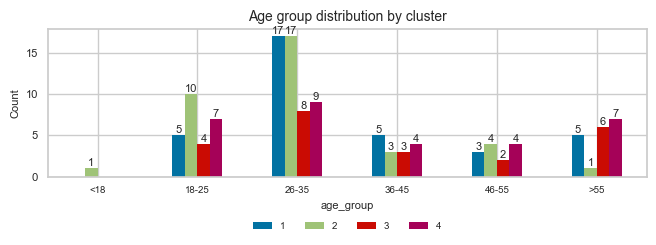

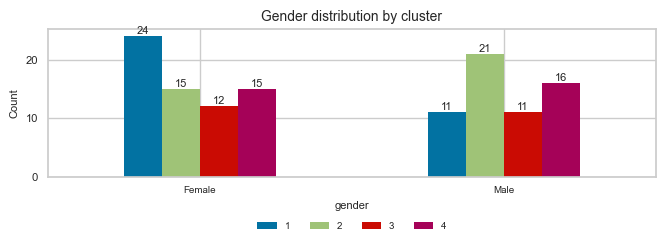

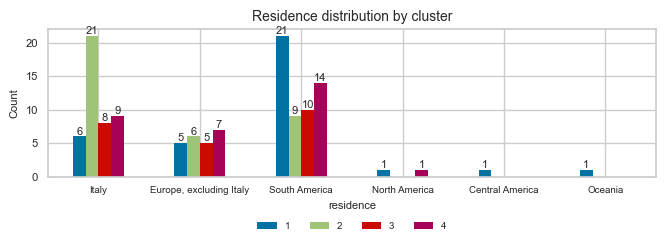

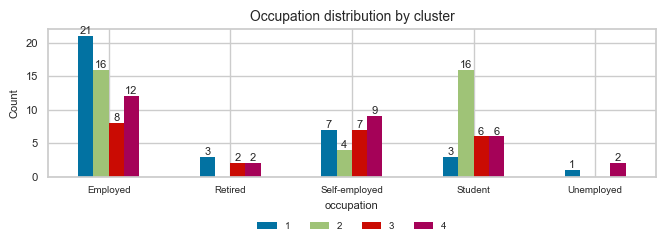

In [1512]:
# age_group
plot_descriptor("age_group", order=age_order)

# gender
plot_descriptor("gender")

# residence
plot_descriptor("residence", order=residence_order)

# occupation
plot_descriptor("occupation")

## Top 3 Attributes by Cluster

In [1513]:
median = df_attributes.groupby("cluster").median()

def highlight_top_bottom3(row):
    top3 = row.nlargest(3).index
    bottom3 = row.nsmallest(3).index
    return [
        'background-color: green' if col in top3
        else 'background-color: red' if col in bottom3
        else ''
        for col in row.index
    ]

styled = median.style.apply(highlight_top_bottom3, axis=1).format("{:.0f}")
styled

,Diversity of authentic local restaurants,Density of touristic attractions within walking distance,City located outside major tourist circuits,"Availability of tourist information, both digital and on-site",Availability of centrally located accommodation,Availability of museums and art venues,"Accommodation services, such as flexible cancellation, digital check-in, amenities, etc.",Heritage ambience of the historic center,Proximity to natural areas or outdoor routes,Flexible scheduling of guided tours
cluster,,,,,,,,,,
1,3,3,8,6,3,6,7,3,4,9
2,4,4,9,8,4,4,5,1,7,9
3,6,8,7,5,2,5,2,5,6,8
4,2,10,6,7,5,3,8,1,4,9


## Accommodation Booking Time

In [1514]:
df_accommodation = df_descriptors[['cluster', 'define_accommodation']]

# Remove spanish translation
df_accommodation['define_accommodation'] = df_accommodation['define_accommodation'].str.replace(r"\s*\(.*\)", "", regex=True)

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\4054952229.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_accommodation['define_accommodation'] = df_accommodation['define_accommodation'].str.replace(r"\s*\(.*\)", "", regex=True)


In [1515]:
counts = pd.crosstab(df_accommodation['cluster'], df_accommodation['define_accommodation'])

def highlight_extremes(col):
    return [
        'background-color: green; font-weight:bold' if v == col.max() else
        ''
        for v in col
    ]

counts.style.apply(highlight_extremes, axis=1)

define_accommodation,…book at the last minute,…book directly at the destination,…book in advance during the planning phase
cluster,,,
1,4,1,30
2,3,0,33
3,0,0,23
4,3,1,27


In [1516]:
# Remove spanihs translation
accommodation_search.columns = accommodation_search.columns.str.replace(r"\s*\(.*?\)", "", regex=True)

df_accommodation_search = accommodation_search.iloc[:,:6]

df_final_accommodation = df_accommodation.copy()

df_final_accommodation = pd.concat([df_final_accommodation, df_accommodation_search], axis=1)

df_final_accommodation.head(2)

,cluster,define_accommodation,Online platforms as Booking,Airbnb,Google,Hotels' official website,Travel agencies,Personal recommendation
0,1,…book at the last minute,1,1,0,0,0,0
1,4,…book in advance during the planning phase,1,0,1,0,0,0


### Booking In Advance

In [1517]:
df_advance = df_final_accommodation[df_final_accommodation['define_accommodation'] == '…book in advance during the planning phase']

counts = df_advance.groupby('cluster')[[
    col for col in df_advance.columns 
    if col not in ['cluster', 'define_accommodation']
]].sum()

size = counts.div(counts.sum(axis=1), axis=0) * 100

def highlight_top_bottom(s):
    return ['background-color: green' if v == s.max()
            else 'background-color: red' if v == s.min()
            else '' for v in s]

counts.style.apply(highlight_top_bottom, axis=1)

,Online platforms as Booking,Airbnb,Google,Hotels' official website,Travel agencies,Personal recommendation
cluster,,,,,,
1,24,17,1,8,3,4
2,31,21,2,5,3,2
3,20,10,3,5,1,0
4,21,13,3,5,4,6


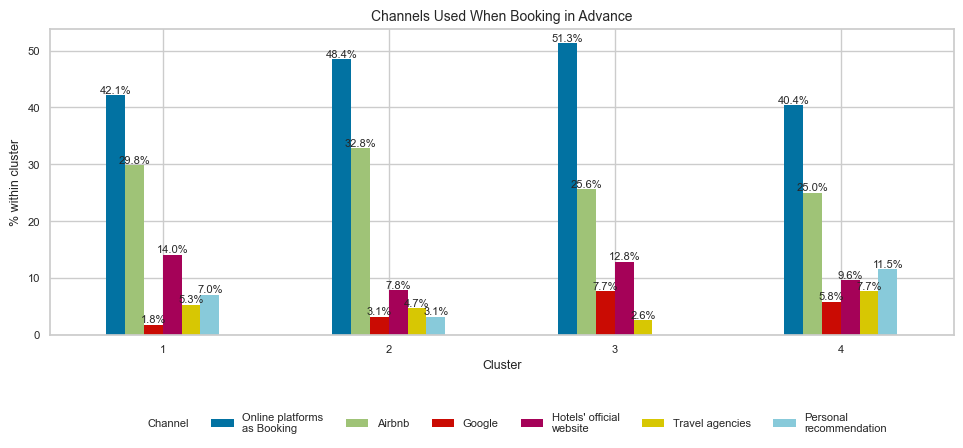

In [1518]:
# Plot
ax = size.plot(kind='bar', figsize=(10,5), fontsize=8)

plt.xlabel("Cluster", fontsize=9)
plt.ylabel("% within cluster", fontsize=9)
plt.xticks(rotation=0)

plt.title("Channels Used When Booking in Advance", fontsize=10)

handles, labels = ax.get_legend_handles_labels()

labels = ['\n'.join(textwrap.wrap(l, 16)) for l in labels]

handles.insert(0, Rectangle((0,0),1,1, fc="none", ec="none"))
labels.insert(0, "Channel")

plt.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=len(labels),
    fontsize=8,
    frameon=False
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(
            f"{h:.1f}%",
            (p.get_x() + p.get_width()/2., h),
            ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.show()

### Booking Last Minute

In [1519]:
df_last_minute = df_final_accommodation[df_final_accommodation['define_accommodation'] == '…book at the last minute']

counts = df_last_minute.groupby('cluster')[[
    col for col in df_last_minute.columns 
    if col not in ['cluster', 'define_accommodation']
]].sum()

size = counts.div(counts.sum(axis=1), axis=0) * 100

def highlight_top_bottom(s):
    return ['background-color: green' if v == s.max()
            else 'background-color: red' if v == s.min()
            else '' for v in s]

counts.style.apply(highlight_top_bottom, axis=1)

,Online platforms as Booking,Airbnb,Google,Hotels' official website,Travel agencies,Personal recommendation
cluster,,,,,,
1,3,3,0,0,0,1
2,3,0,0,1,0,1
4,2,0,1,2,0,0


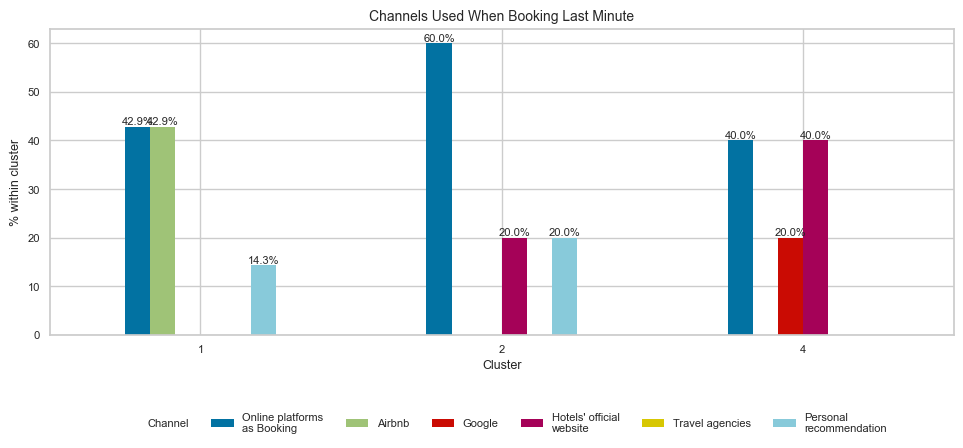

In [1520]:
# Plot
ax = size.plot(kind='bar', figsize=(10,5), fontsize=8)

plt.xlabel("Cluster", fontsize=9)
plt.ylabel("% within cluster", fontsize=9)
plt.xticks(rotation=0)

plt.title("Channels Used When Booking Last Minute", fontsize=10)

handles, labels = ax.get_legend_handles_labels()

labels = ['\n'.join(textwrap.wrap(l, 16)) for l in labels]

handles.insert(0, Rectangle((0,0),1,1, fc="none", ec="none"))
labels.insert(0, "Channel")

plt.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=len(labels),
    fontsize=8,
    frameon=False
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(
            f"{h:.1f}%",
            (p.get_x() + p.get_width()/2., h),
            ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.show()

## Less Known Cities

In [1521]:
mapping = {
    "Up to 30 minutes (Hasta 30 minutos)": 1,
    "1–2 hours (1-2 horas)": 2,
    "3–4 hours (3-4 horas)": 3,
    "More than 4 hours (Más de 4 horas)": 4,
    "I wouldn’t travel longer for that reason (No viajaría más por esa razón)": 5
}

df_descriptors["extra_travel_time_num"] = df_descriptors["extra_travel_time"].map(mapping)

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\2756981465.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_descriptors["extra_travel_time_num"] = df_descriptors["extra_travel_time"].map(mapping)


[25-10-2025 18:36:24] [matplotlib.category] [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[25-10-2025 18:36:24] [matplotlib.category] [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


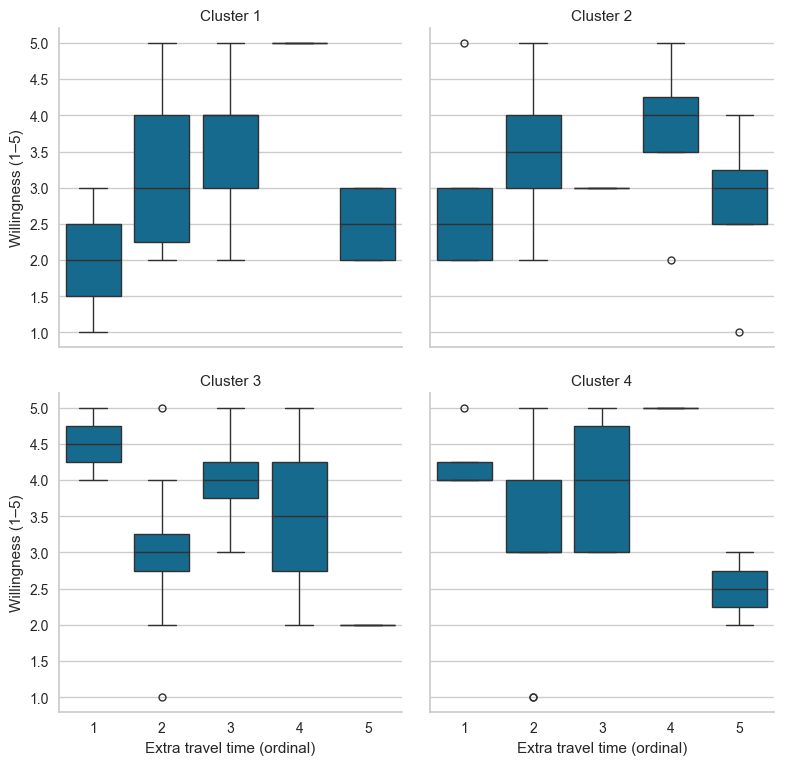

In [1522]:
g = sns.catplot(
    data=df_descriptors,
    x="extra_travel_time_num",
    y="less_crowded_willingness",
    col="cluster",
    kind="box",
    col_wrap=2,   # cantidad por fila
    height=4,
    aspect=1
)

g.set_titles("Cluster {col_name}")
g.set_axis_labels("Extra travel time (ordinal)", "Willingness (1–5)")
plt.show()

## City Tour Analysis

### City Tour: Yes

In [1523]:
df_city_tour = df_descriptors[df_descriptors['city_tour_type'].notna()][['cluster', 'city_tour_type']]

# Remove spanish translation
df_city_tour['city_tour_type'] = df_city_tour['city_tour_type'].str.replace(r"\s*\(.*\)", "", regex=True)

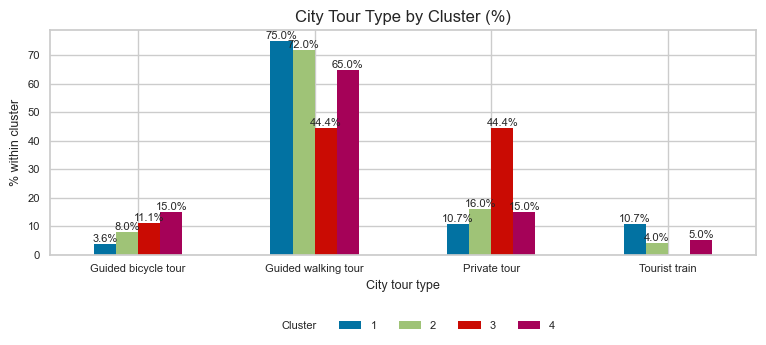

In [1524]:
# Count table
counts = pd.crosstab(df_city_tour['city_tour_type'], df_city_tour['cluster'])

# Percentage by cluster (column)
percent = counts.div(counts.sum(axis=0), axis=1) * 100

# Plot
ax = percent.plot(kind='bar', figsize=(8,4), fontsize=8)

plt.xlabel("City tour type", fontsize=9)
plt.ylabel("% within cluster", fontsize=9)
plt.xticks(rotation=360)

plt.title("City Tour Type by Cluster (%)")

handles, labels = ax.get_legend_handles_labels()

handles.insert(0, Rectangle((0,0),1,1, fc="none", ec="none"))
labels.insert(0, "Cluster")

plt.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=len(labels),
    fontsize=8,
    frameon=False
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(
            f"{h:.1f}%",
            (p.get_x() + p.get_width()/2., h),
            ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.show()

In [1525]:
counts

cluster,1,2,3,4
city_tour_type,,,,
Guided bicycle tour,1,2,2,3
Guided walking tour,21,18,8,13
Private tour,3,4,8,3
Tourist train,3,1,0,1


### City Tour: No

In [1526]:
df_no_city_tour = architectural_interest.iloc[:,1:]

# Remove spanish translation
df_no_city_tour.columns = df_no_city_tour.columns.str.replace(r"\s*\(.*\)", "", regex=True)

df_no_city_tour['cluster'] = df_clustering['cluster']

df_no_city_tour

,"Medieval architecture: towers, fortifications, bridges.",Historical squares and public spaces,Museums and cultural centers,Renaissance and Baroque palaces,"Religious buildings: churches, cathedrals, monasteries.",Modern or contemporary architecture,cluster
0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,4
2,0,0,0,0,0,0,1
3,0,0,0,0,0,0,2
4,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...
120,0,0,0,0,0,0,3
121,0,0,0,0,0,0,4
122,0,0,0,0,0,0,3
123,0,0,0,0,0,0,3


C:\Users\franc\AppData\Local\Temp\ipykernel_12100\3232766604.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(t)}%" for t in ax.get_yticks()])


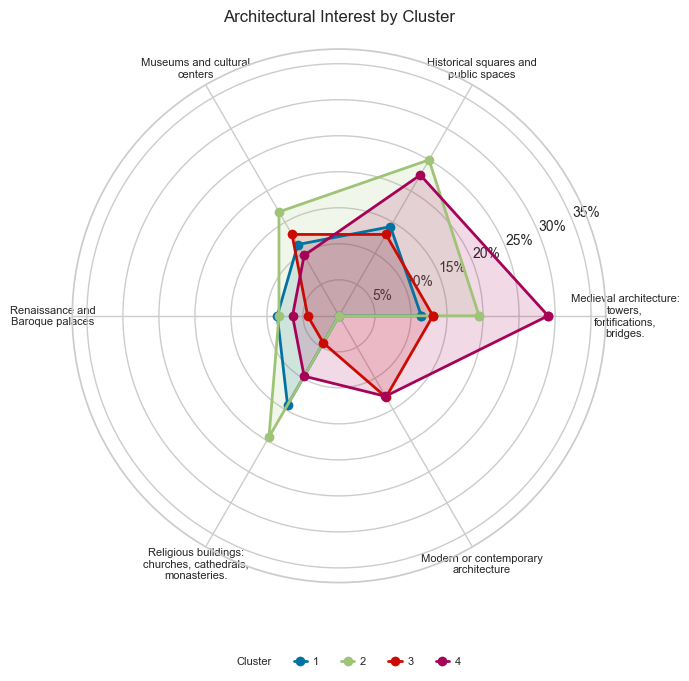

In [1527]:
import textwrap

df_radar = df_no_city_tour.groupby("cluster").mean() * 100

labels = ["\n".join(textwrap.wrap(l, width=22)) for l in df_radar.columns]
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

fig = plt.figure(figsize=(7.2,7.2))
ax = fig.add_subplot(111, polar=True)

color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
clusters = list(df_radar.index)

line_handles = []
for i, c in enumerate(clusters):
    vals = df_radar.loc[c].values
    vals = np.concatenate((vals, [vals[0]]))
    line, = ax.plot(angles, vals, linewidth=2, marker='o', color=color_cycle[i % len(color_cycle)])
    ax.fill(angles, vals, alpha=0.15, color=color_cycle[i % len(color_cycle)])
    line_handles.append(line)

ax.set_thetagrids(angles[:-1] * 180/np.pi, labels, fontsize=8)
ax.set_ylim(0, df_radar.values.max() + 8)
ax.set_yticklabels([f"{int(t)}%" for t in ax.get_yticks()])
plt.title("Architectural Interest by Cluster", pad=20, fontsize=12)

dummy = Rectangle((0,0), 1, 1, fc="none", ec="none")
plt.legend(
    [dummy] + line_handles,
    ["Cluster"] + [str(c) for c in clusters],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),   # más cerca del radar
    ncol=len(clusters) + 1,
    fontsize=8,
    frameon=False,
    handlelength=1.2,   # más corto
    handletextpad=0.5,  # menos espacio texto-handle
)

plt.tight_layout()
plt.show()

In [1528]:
def highlight_extremes(col):
    return ['background-color: green' if v == col.max() else
            'background-color: red' if v == col.min() else ''
            for v in col]

df_radar.style.apply(highlight_extremes, axis=1)

,"Medieval architecture: towers, fortifications, bridges.",Historical squares and public spaces,Museums and cultural centers,Renaissance and Baroque palaces,"Religious buildings: churches, cathedrals, monasteries.",Modern or contemporary architecture
cluster,,,,,,
1,11.428571,14.285714,11.428571,8.571429,14.285714,0.000000
2,19.444444,25.000000,16.666667,8.333333,19.444444,0.000000
3,13.043478,13.043478,13.043478,4.347826,4.347826,13.043478
4,29.032258,22.580645,9.677419,6.451613,9.677419,12.903226


## Place to Eat

In [1529]:
df_eating = df_descriptors[['cluster', 'eating_preference']]

# Remove spanish translation
df_eating['eating_preference'] = df_eating['eating_preference'].str.replace(r"\s*\(.*\)", "", regex=True)

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\110575802.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eating['eating_preference'] = df_eating['eating_preference'].str.replace(r"\s*\(.*\)", "", regex=True)


In [1530]:
counts = pd.crosstab(df_eating['cluster'], df_eating['eating_preference'])

def highlight_extremes(col):
    return [
        'background-color: green; font-weight:bold' if v == col.max() else
        ''
        for v in col
    ]

counts.style.apply(highlight_extremes, axis=1)

eating_preference,"In less crowded, local neighborhoods",In the historic center,In tourist areas,It doesn’t matter to me,Near my accommodation
cluster,,,,,
1,12,5,2,11,5
2,17,6,1,8,4
3,7,3,4,7,2
4,13,2,3,9,4


In [1531]:
# Remove spanihs translation
restaurant_choice.columns = restaurant_choice.columns.str.replace(r"\s*\(.*?\)", "", regex=True)

df_restaurant_choice = restaurant_choice.iloc[:,:5]

df_final_eating = df_eating.copy()

df_final_eating = pd.concat([df_final_eating, df_restaurant_choice], axis=1)

df_final_eating.head(2)

,cluster,eating_preference,I decide while walking by,Based on personal recommendations,Based on online reviews as Google Maps,Based on location,I search and book in advance
0,1,It doesn’t matter to me,1,0,0,0,0
1,4,Near my accommodation,0,1,0,0,0


In [1532]:
df_walking = df_final_eating[df_final_eating['eating_preference'] == 'In less crowded, local neighborhoods']

counts = df_walking.groupby('cluster')[[
    col for col in df_walking.columns 
    if col not in ['cluster', 'eating_preference']
]].sum()

size = counts.div(counts.sum(axis=1), axis=0) * 100

def highlight_top_bottom(s):
    return ['background-color: green' if v == s.max()
            else 'background-color: red' if v == s.min()
            else '' for v in s]

counts.style.apply(highlight_top_bottom, axis=1)

,I decide while walking by,Based on personal recommendations,Based on online reviews as Google Maps,Based on location,I search and book in advance
cluster,,,,,
1,6,4,11,1,2
2,9,7,9,1,5
3,2,3,5,1,2
4,7,7,3,0,4


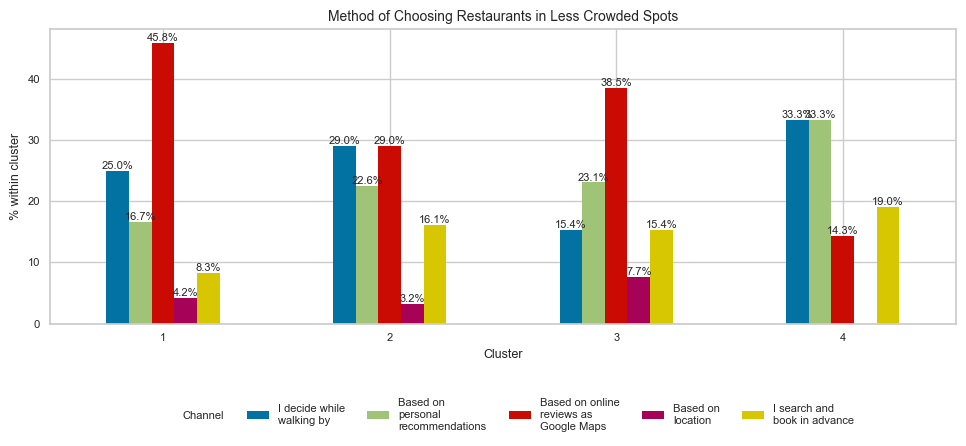

In [1533]:
# Plot
ax = size.plot(kind='bar', figsize=(10,5), fontsize=8)

plt.xlabel("Cluster", fontsize=9)
plt.ylabel("% within cluster", fontsize=9)
plt.xticks(rotation=0)

plt.title("Method of Choosing Restaurants in Less Crowded Spots", fontsize=10)

handles, labels = ax.get_legend_handles_labels()

labels = ['\n'.join(textwrap.wrap(l, 16)) for l in labels]

handles.insert(0, Rectangle((0,0),1,1, fc="none", ec="none"))
labels.insert(0, "Channel")

plt.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=len(labels),
    fontsize=8,
    frameon=False
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(
            f"{h:.1f}%",
            (p.get_x() + p.get_width()/2., h),
            ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.show()

## Natural Spots

In [1534]:
df_natural_spots = natural_environment_type.iloc[:,:4]

# Remove spanihs translation
df_natural_spots.columns = df_natural_spots.columns.str.replace(r"\s*\(.*?\)", "", regex=True)

df_natural_spots['cluster'] = df_clustering['cluster']

df_natural_spots.head(2)

C:\Users\franc\AppData\Local\Temp\ipykernel_12100\840162339.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_natural_spots['cluster'] = df_clustering['cluster']


,Beach,Natural parks,Mountains,Lake/Rivers,cluster
0,1,1,0,0,1
1,1,0,0,0,4


In [1535]:
counts = df_natural_spots.groupby("cluster").sum()
counts.style.apply(highlight_extremes, axis=1)

,Beach,Natural parks,Mountains,Lake/Rivers
cluster,,,,
1,23,14,18,12
2,27,10,18,11
3,17,8,11,6
4,19,13,16,9


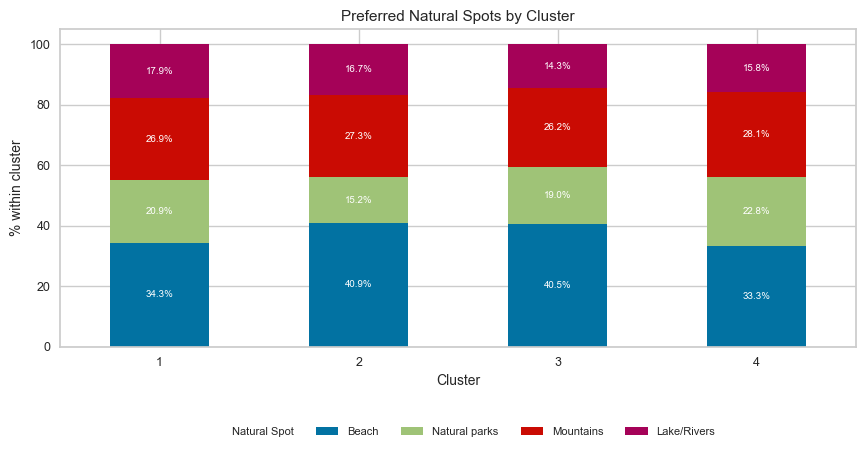

In [1536]:
percent = counts.div(counts.sum(axis=1), axis=0) * 100

ax = percent.plot(kind='bar', stacked=True, figsize=(9,5), fontsize=9)

plt.title("Preferred Natural Spots by Cluster", fontsize=11)
plt.xlabel("Cluster", fontsize=10)
plt.ylabel("% within cluster", fontsize=10)
plt.xticks(rotation=0)

handles, labels = ax.get_legend_handles_labels()

labels = ['\n'.join(textwrap.wrap(l, 16)) for l in labels]

handles.insert(0, Rectangle((0,0),1,1, fc="none", ec="none"))
labels.insert(0, "Natural Spot")

plt.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=len(labels),
    fontsize=8,
    frameon=False
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(
            f"{h:.1f}%",
            (p.get_x() + p.get_width()/2., p.get_y() + h/2),
            ha='center', va='center',
            fontsize=7, color="white"
        )

plt.tight_layout()
plt.show()